# Day 2: Titanic EDA, Visualization, and Statistics

This notebook is a complete, runnable example of how Python turns **raw data into evidence**.

We will follow one repeatable workflow:

> **Load → Inspect → Audit → Clean → Transform → Summarize → Visualize → Explain**

### Learning goals

- Read a CSV directly from a URL with Pandas.
- Inspect structure, data types, missing values, and duplicates.
- Clean missing data without hiding what changed.
- Engineer useful features such as family size and age group.
- Calculate descriptive statistics and conditional probabilities.
- Build clear Matplotlib and Seaborn visualizations.
- Turn charts into a short, evidence-based EDA report.

The dataset contains 891 Titanic passengers. `survived = 1` means the passenger survived; `0` means the passenger did not survive.

## 0. Setup and visual style

Run this cell first. A consistent theme, color palette, and figure size make every later chart easier to compare.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from IPython.display import display

%matplotlib inline
%config InlineBackend.figure_format = "retina"

sns.set_theme(style="whitegrid", context="notebook")
COLORS = {
    "died": "#D55E00",
    "survived": "#009E73",
    "primary": "#0072B2",
    "accent": "#E69F00",
    "neutral": "#7A7A7A",
}
CLASS_ORDER = ["First", "Second", "Third"]

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

print("Pandas:", pd.__version__)
print("Seaborn:", sns.__version__)

Pandas: 2.2.3
Seaborn: 0.13.2


## 1. Load the raw data

`pd.read_csv()` downloads the comma-separated file and converts it into a DataFrame. We keep an untouched `raw_df` copy so that cleaning decisions remain auditable.

In [2]:
from pathlib import Path

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
local_candidates = [Path("../datasets/titanic.csv"), Path("datasets/titanic.csv")]

try:
    raw_df = pd.read_csv(url)
    data_source = url
except Exception as download_error:
    local_path = next((path for path in local_candidates if path.is_file()), None)
    if local_path is None:
        raise RuntimeError(
            "Could not download Titanic data and no local course snapshot was found."
        ) from download_error
    raw_df = pd.read_csv(local_path)
    data_source = str(local_path.resolve())

df = raw_df.copy()

expected_columns = {
    "survived", "pclass", "sex", "age", "sibsp", "parch", "fare",
    "embarked", "class", "who", "adult_male", "deck", "embark_town",
    "alive", "alone",
}
if set(df.columns) != expected_columns:
    raise ValueError("The Titanic schema does not match the expected 15 columns.")
if len(df) != 891:
    raise ValueError(f"Expected 891 Titanic rows, received {len(df)}.")

print(f"Data source: {data_source}")
print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns")
display(df.head())

Data source: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv
Loaded 891 rows and 15 columns


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.00,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.00,1,0,71.28,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.00,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.00,1,0,53.10,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.00,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True


### Data dictionary

| Column | Meaning |
|---|---|
| `survived` | 1 = survived, 0 = did not survive |
| `pclass` / `class` | Passenger class: 1/First, 2/Second, 3/Third |
| `sex` | Recorded sex |
| `age` | Age in years |
| `sibsp` | Number of siblings/spouses aboard |
| `parch` | Number of parents/children aboard |
| `fare` | Ticket fare |
| `embarked` / `embark_town` | Port of embarkation |
| `who` | Man, woman, or child |
| `adult_male` | Whether the passenger was an adult male |
| `deck` | Cabin deck letter |
| `alive` | Yes/no version of `survived` |
| `alone` | Whether the passenger travelled alone |

Some columns describe the same concept in different forms. That is useful for teaching, but we should avoid counting redundant columns as independent evidence.

## 2. Inspect: what did Python receive?

Start broad: dimensions, column names, data types, and a few examples. `info()` also shows how many non-missing values each column contains.

In [3]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nData types:")
display(df.dtypes.rename("dtype").to_frame())
print("\nDataFrame info:")
df.info()

Shape: (891, 15)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data types:


,dtype
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,object
who,object



DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [4]:
# Numeric summaries answer: center, spread, range, and quartiles.
display(df.describe().T)

# Categorical summaries answer: how many distinct values and which is most common?
display(df.describe(include=["object", "category", "bool"]).T)

,count,mean,std,min,25%,50%,75%,max
survived,891.00,0.38,0.49,0.00,0.00,0.00,1.00,1.00
pclass,891.00,2.31,0.84,1.00,2.00,3.00,3.00,3.00
age,714.00,29.70,14.53,0.42,20.12,28.00,38.00,80.00
sibsp,891.00,0.52,1.10,0.00,0.00,0.00,1.00,8.00
parch,891.00,0.38,0.81,0.00,0.00,0.00,0.00,6.00
fare,891.00,32.20,49.69,0.00,7.91,14.45,31.00,512.33


,count,unique,top,freq
sex,891,2,male,577
embarked,889,3,S,644
class,891,3,Third,491
who,891,3,man,537
adult_male,891,2,True,537
deck,203,7,C,59
embark_town,889,3,Southampton,644
alive,891,2,no,549
alone,891,2,True,537


## 3. Audit data quality

Before plotting, check missing values, duplicates, and impossible values. A chart built on misunderstood data can look polished and still be wrong.

In [5]:
missing_audit = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean().mul(100),
        "dtype": df.dtypes.astype(str),
        "unique_values": df.nunique(dropna=True),
    })
    .sort_values("missing_percent", ascending=False)
)

print("Duplicate rows:", df.duplicated().sum())
display(missing_audit)

Duplicate rows: 107


,missing_count,missing_percent,dtype,unique_values
deck,688,77.22,object,7
age,177,19.87,float64,88
embarked,2,0.22,object,3
embark_town,2,0.22,object,3
survived,0,0.00,int64,2
pclass,0,0.00,int64,3
sex,0,0.00,object,2
sibsp,0,0.00,int64,7
parch,0,0.00,int64,7
fare,0,0.00,float64,248


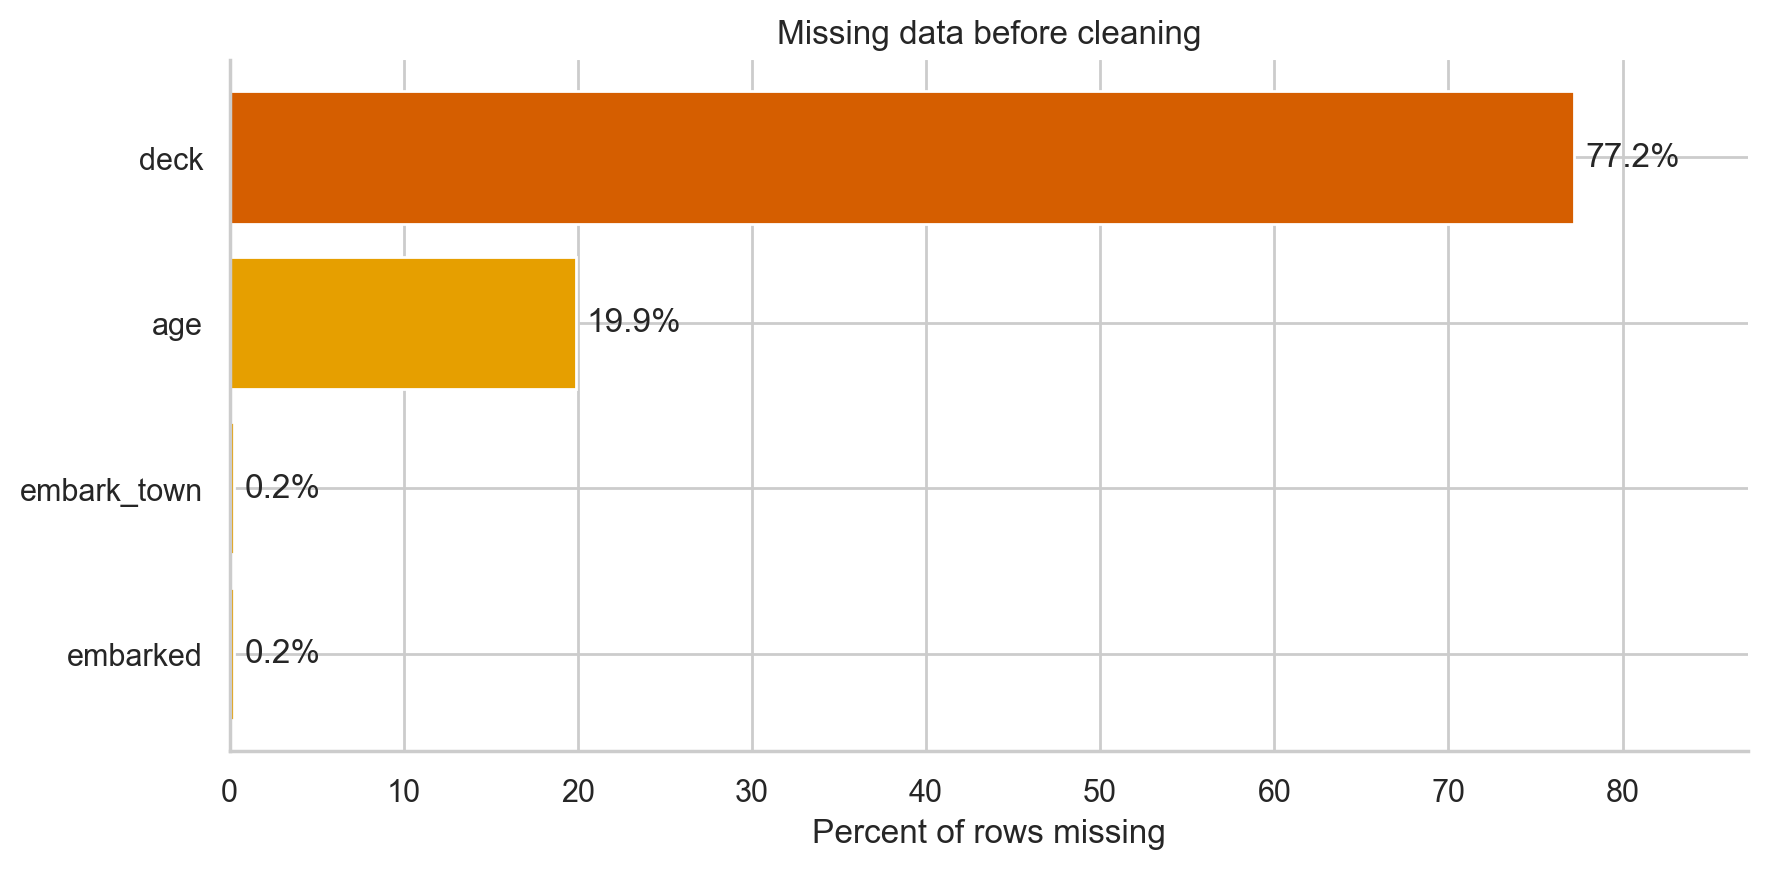

In [6]:
# VISUAL 1 — Missingness makes the cleaning priorities immediately visible.
missing_plot = missing_audit.query("missing_count > 0").sort_values("missing_percent")

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(
    missing_plot.index,
    missing_plot["missing_percent"],
    color=[COLORS["accent"] if value < 50 else COLORS["died"] for value in missing_plot["missing_percent"]],
)
ax.bar_label(bars, fmt="%.1f%%", padding=4)
ax.set(title="Missing data before cleaning", xlabel="Percent of rows missing", ylabel="")
ax.set_xlim(0, max(85, missing_plot["missing_percent"].max() + 10))
sns.despine()
plt.tight_layout()
plt.show()

In [7]:
# Simple validity checks: these should all be zero for this dataset.
validity_checks = pd.Series({
    "invalid survival labels": (~df["survived"].isin([0, 1])).sum(),
    "invalid passenger classes": (~df["pclass"].isin([1, 2, 3])).sum(),
    "negative ages": df["age"].lt(0).sum(),
    "negative fares": df["fare"].lt(0).sum(),
}, name="problem_rows")

display(validity_checks.to_frame())

,problem_rows
invalid survival labels,0
invalid passenger classes,0
negative ages,0
negative fares,0


## 4. Clean and transform

Cleaning is not simply “delete every incomplete row.” Each column needs a decision:

- **Age:** fill with the median for passengers of the same class and sex. This keeps all rows and uses relevant group information.
- **Embarkation:** fill the two missing values with the most common port.
- **Deck:** more than three quarters are missing, so preserve that fact as an explicit `Unknown` category.
- **Duplicates:** do not remove them automatically. This teaching dataset omits names/ticket IDs, so two passengers can legitimately share the same visible values.

Then create analysis-friendly features. Feature engineering turns raw columns into concepts that answer better questions.

In [8]:
cleaning_log = []

# 1. Record which ages were originally missing, then impute within similar groups.
age_missing_before = df["age"].isna().sum()
df["age_was_missing"] = df["age"].isna()
group_age_median = df.groupby(["pclass", "sex"])["age"].transform("median")
df["age"] = df["age"].fillna(group_age_median)
cleaning_log.append(("age", age_missing_before, df["age"].isna().sum(), "class + sex median"))

# 2. Fill the embarkation code, then derive the matching town from that code.
embarked_before = df["embarked"].isna().sum()
town_before = df["embark_town"].isna().sum()
df["embarked"] = df["embarked"].fillna(df["embarked"].mode().iloc[0])
port_to_town = {"C": "Cherbourg", "Q": "Queenstown", "S": "Southampton"}
df["embark_town"] = df["embarked"].map(port_to_town)
cleaning_log.append(("embarked", embarked_before, df["embarked"].isna().sum(), "most common code"))
cleaning_log.append(("embark_town", town_before, df["embark_town"].isna().sum(), "derived from embarkation code"))

# 3. Keep missing deck information rather than inventing a deck letter.
deck_missing_before = df["deck"].isna().sum()
df["deck"] = df["deck"].astype("object").fillna("Unknown")
cleaning_log.append(("deck", deck_missing_before, df["deck"].isna().sum(), "explicit Unknown category"))

cleaning_summary = pd.DataFrame(
    cleaning_log,
    columns=["column", "missing_before", "missing_after", "method"],
)
display(cleaning_summary)

,column,missing_before,missing_after,method
0,age,177,0,class + sex median
1,embarked,2,0,most common code
2,embark_town,2,0,derived from embarkation code
3,deck,688,0,explicit Unknown category


In [9]:
# Feature engineering: build columns that represent useful human concepts.
df = df.assign(
    family_size=df["sibsp"] + df["parch"] + 1,
    survival_label=df["survived"].map({0: "Died", 1: "Survived"}),
)

df["is_alone"] = np.where(df["family_size"].eq(1), "Alone", "With family")
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 17, 29, 44, 59, np.inf],
    labels=["Child", "Teen", "Young adult", "Adult", "Middle age", "Senior"],
    include_lowest=True,
)
df["fare_log"] = np.log1p(df["fare"])

created_columns = ["age_was_missing", "family_size", "survival_label", "is_alone", "age_group", "fare_log"]
display(df[created_columns].head(10))

,age_was_missing,family_size,survival_label,is_alone,age_group,fare_log
0,False,2,Died,With family,Young adult,2.11
1,False,2,Survived,With family,Adult,4.28
2,False,1,Survived,Alone,Young adult,2.19
3,False,2,Survived,With family,Adult,3.99
4,False,1,Died,Alone,Adult,2.20
5,True,1,Died,Alone,Young adult,2.25
6,False,1,Died,Alone,Middle age,3.97
7,False,5,Died,With family,Child,3.09
8,False,3,Survived,With family,Young adult,2.50
9,False,2,Survived,With family,Teen,3.44


In [10]:
# Validation turns assumptions into executable checks.
assert df[["age", "embarked", "embark_town", "deck"]].isna().sum().sum() == 0
assert df["survived"].isin([0, 1]).all()
assert df["pclass"].isin([1, 2, 3]).all()
assert df["family_size"].ge(1).all()
assert df["embark_town"].eq(df["embarked"].map(port_to_town)).all()
assert len(df) == len(raw_df), "Cleaning unexpectedly changed the row count"

print("All cleaning checks passed.")
print(f"Rows preserved: {len(df):,} of {len(raw_df):,}")
print(f"New analysis columns: {', '.join(created_columns)}")

All cleaning checks passed.
Rows preserved: 891 of 891
New analysis columns: age_was_missing, family_size, survival_label, is_alone, age_group, fare_log


### Check the effect of age imputation

Imputation preserves rows but changes the distribution: the missing ages become repeated group medians. Compare raw observed ages with the processed column before interpreting age-related patterns.

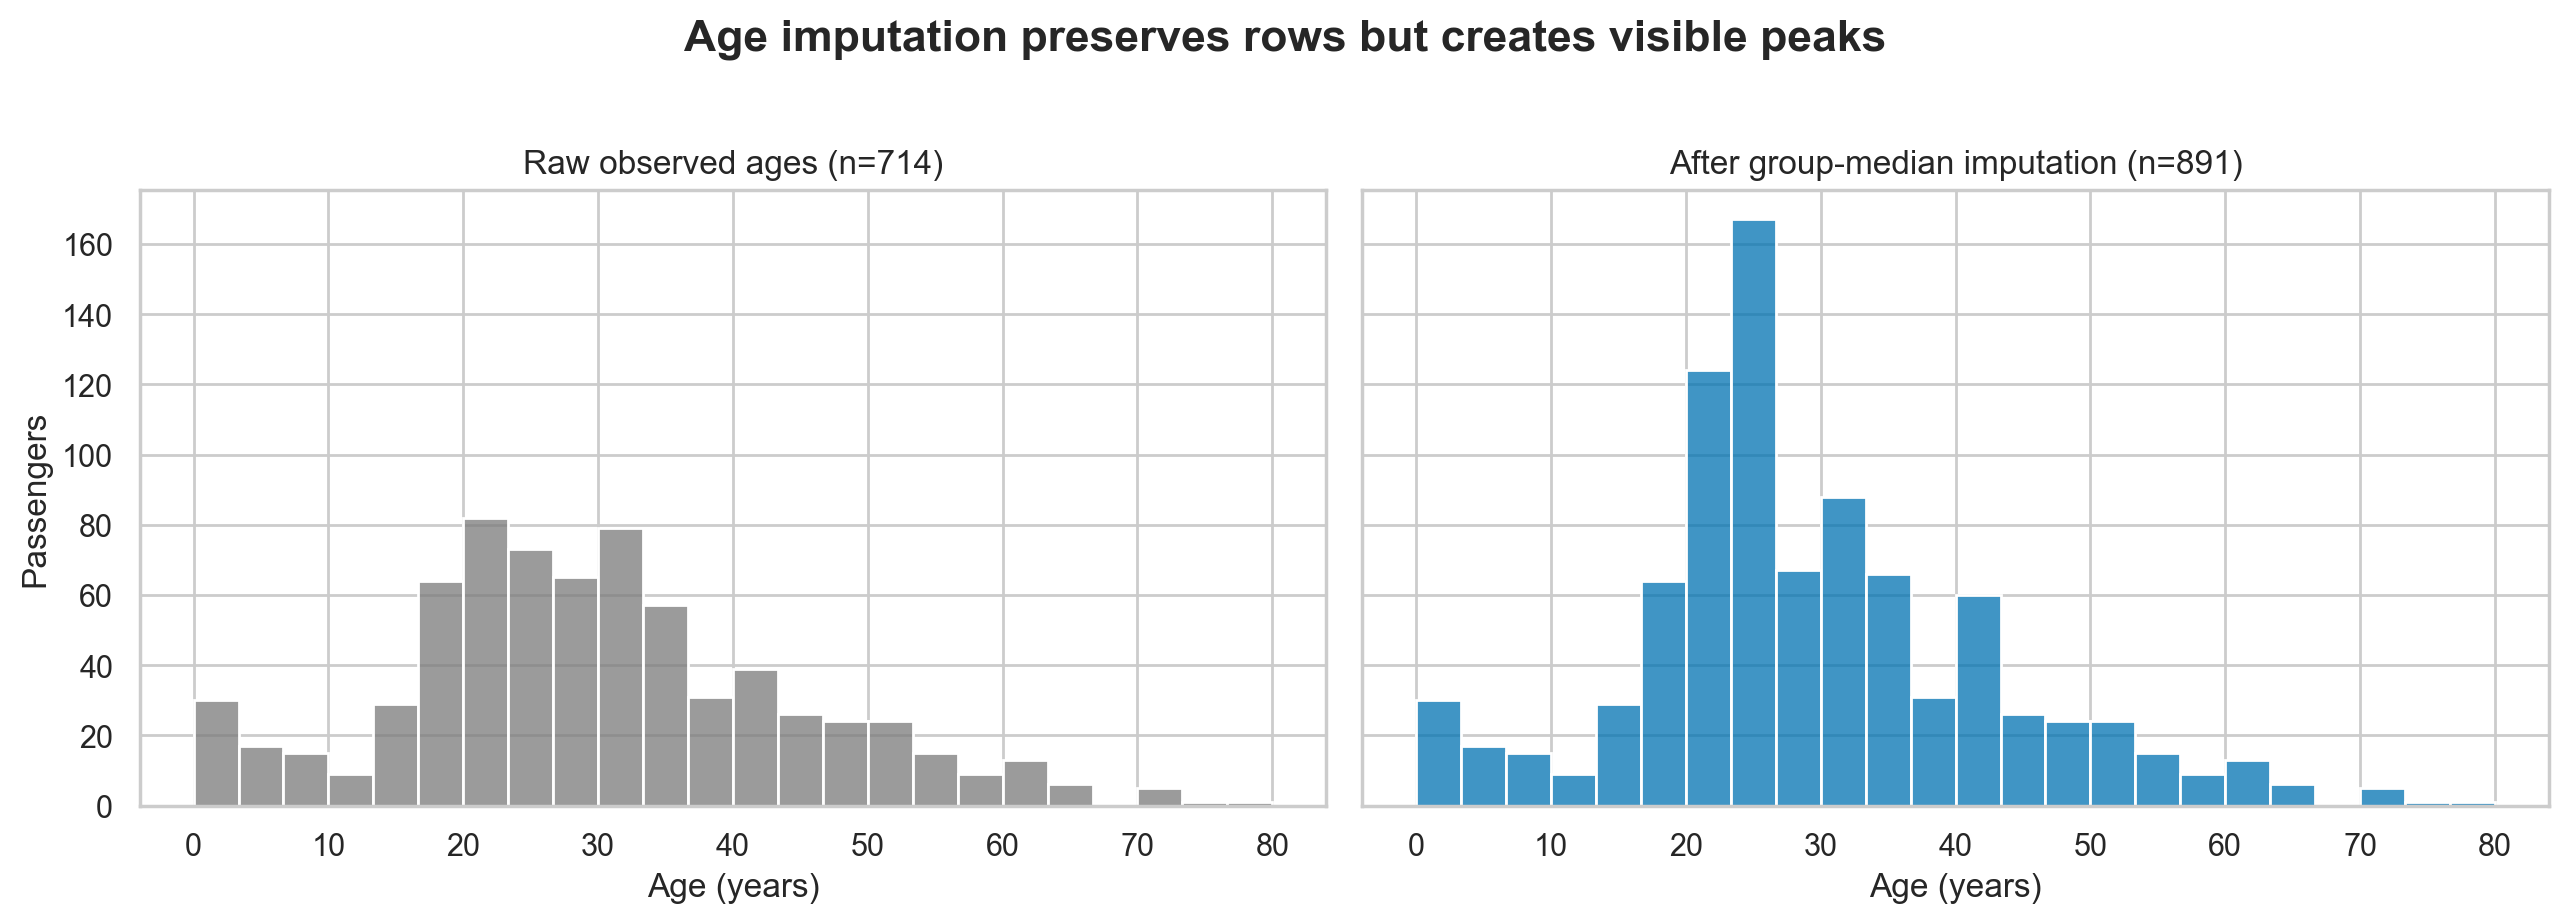

Age–survival correlation using observed ages only: r = -0.077
Age–survival correlation after imputation:       r = -0.060


In [11]:
# VISUAL 2 — The processing step itself should be visible and measurable.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)

sns.histplot(data=raw_df, x="age", bins=24, binrange=(0, 80), color=COLORS["neutral"], ax=axes[0])
axes[0].set(title=f"Raw observed ages (n={raw_df['age'].notna().sum():,})", xlabel="Age (years)", ylabel="Passengers")

sns.histplot(data=df, x="age", bins=24, binrange=(0, 80), color=COLORS["primary"], ax=axes[1])
axes[1].set(title=f"After group-median imputation (n={len(df):,})", xlabel="Age (years)", ylabel="")

fig.suptitle("Age imputation preserves rows but creates visible peaks", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

raw_age_survival_corr = raw_df[["age", "survived"]].corr().loc["age", "survived"]
imputed_age_survival_corr = df[["age", "survived"]].corr().loc["age", "survived"]
print(f"Age–survival correlation using observed ages only: r = {raw_age_survival_corr:.3f}")
print(f"Age–survival correlation after imputation:       r = {imputed_age_survival_corr:.3f}")

## 5. Descriptive statistics and probability

A statistic compresses many rows into a useful number. Always pair the number with its meaning and, when possible, a visualization.

In [12]:
def descriptive_stats(series):
    return pd.Series({
        "Mean": series.mean(),
        "Median": series.median(),
        "Standard deviation": series.std(),
        "Minimum": series.min(),
        "Q1 (25%)": series.quantile(0.25),
        "Q3 (75%)": series.quantile(0.75),
        "Maximum": series.max(),
    })

stats_table = pd.DataFrame({
    "Age (years)": descriptive_stats(df["age"]),
    "Fare": descriptive_stats(df["fare"]),
})
display(stats_table)

print("Why mean and median differ for fare:")
print(f"  Mean fare   = {df['fare'].mean():.2f}")
print(f"  Median fare = {df['fare'].median():.2f}")
print("  A small number of very high fares pull the mean upward.")

,Age (years),Fare
Mean,29.11,32.20
Median,26.00,14.45
Standard deviation,13.30,49.69
Minimum,0.42,0.00
Q1 (25%),21.50,7.91
Q3 (75%),36.00,31.00
Maximum,80.00,512.33


Why mean and median differ for fare:
  Mean fare   = 32.20
  Median fare = 14.45
  A small number of very high fares pull the mean upward.


In [13]:
# Survival is stored as 0/1, so its mean is the probability of survival.
overall_rate = df["survived"].mean()
by_sex = df.groupby("sex", observed=True)["survived"].agg(["mean", "count"])
by_class = df.groupby("class", observed=True)["survived"].agg(["mean", "count"])

print(f"P(survived) = {overall_rate:.1%} ({df['survived'].sum():,} of {len(df):,} records)")
print("This is a descriptive proportion for these records, not an estimate from a random sample.")
print("\nConditional probability by sex:")
display(by_sex.style.format({"mean": "{:.1%}", "count": "{:,.0f}"}))
print("Conditional probability by class:")
display(by_class.style.format({"mean": "{:.1%}", "count": "{:,.0f}"}))

P(survived) = 38.4% (342 of 891 records)
This is a descriptive proportion for these records, not an estimate from a random sample.

Conditional probability by sex:


,mean,count
sex,,
female,74.2%,314
male,18.9%,577


Conditional probability by class:


,mean,count
class,,
First,63.0%,216
Second,47.3%,184
Third,24.2%,491


## 6. Univariate visualization: understand one variable at a time

Use bar charts for categories and histograms/boxplots for numeric distributions. The goal is to see shape, center, spread, and unusual values.

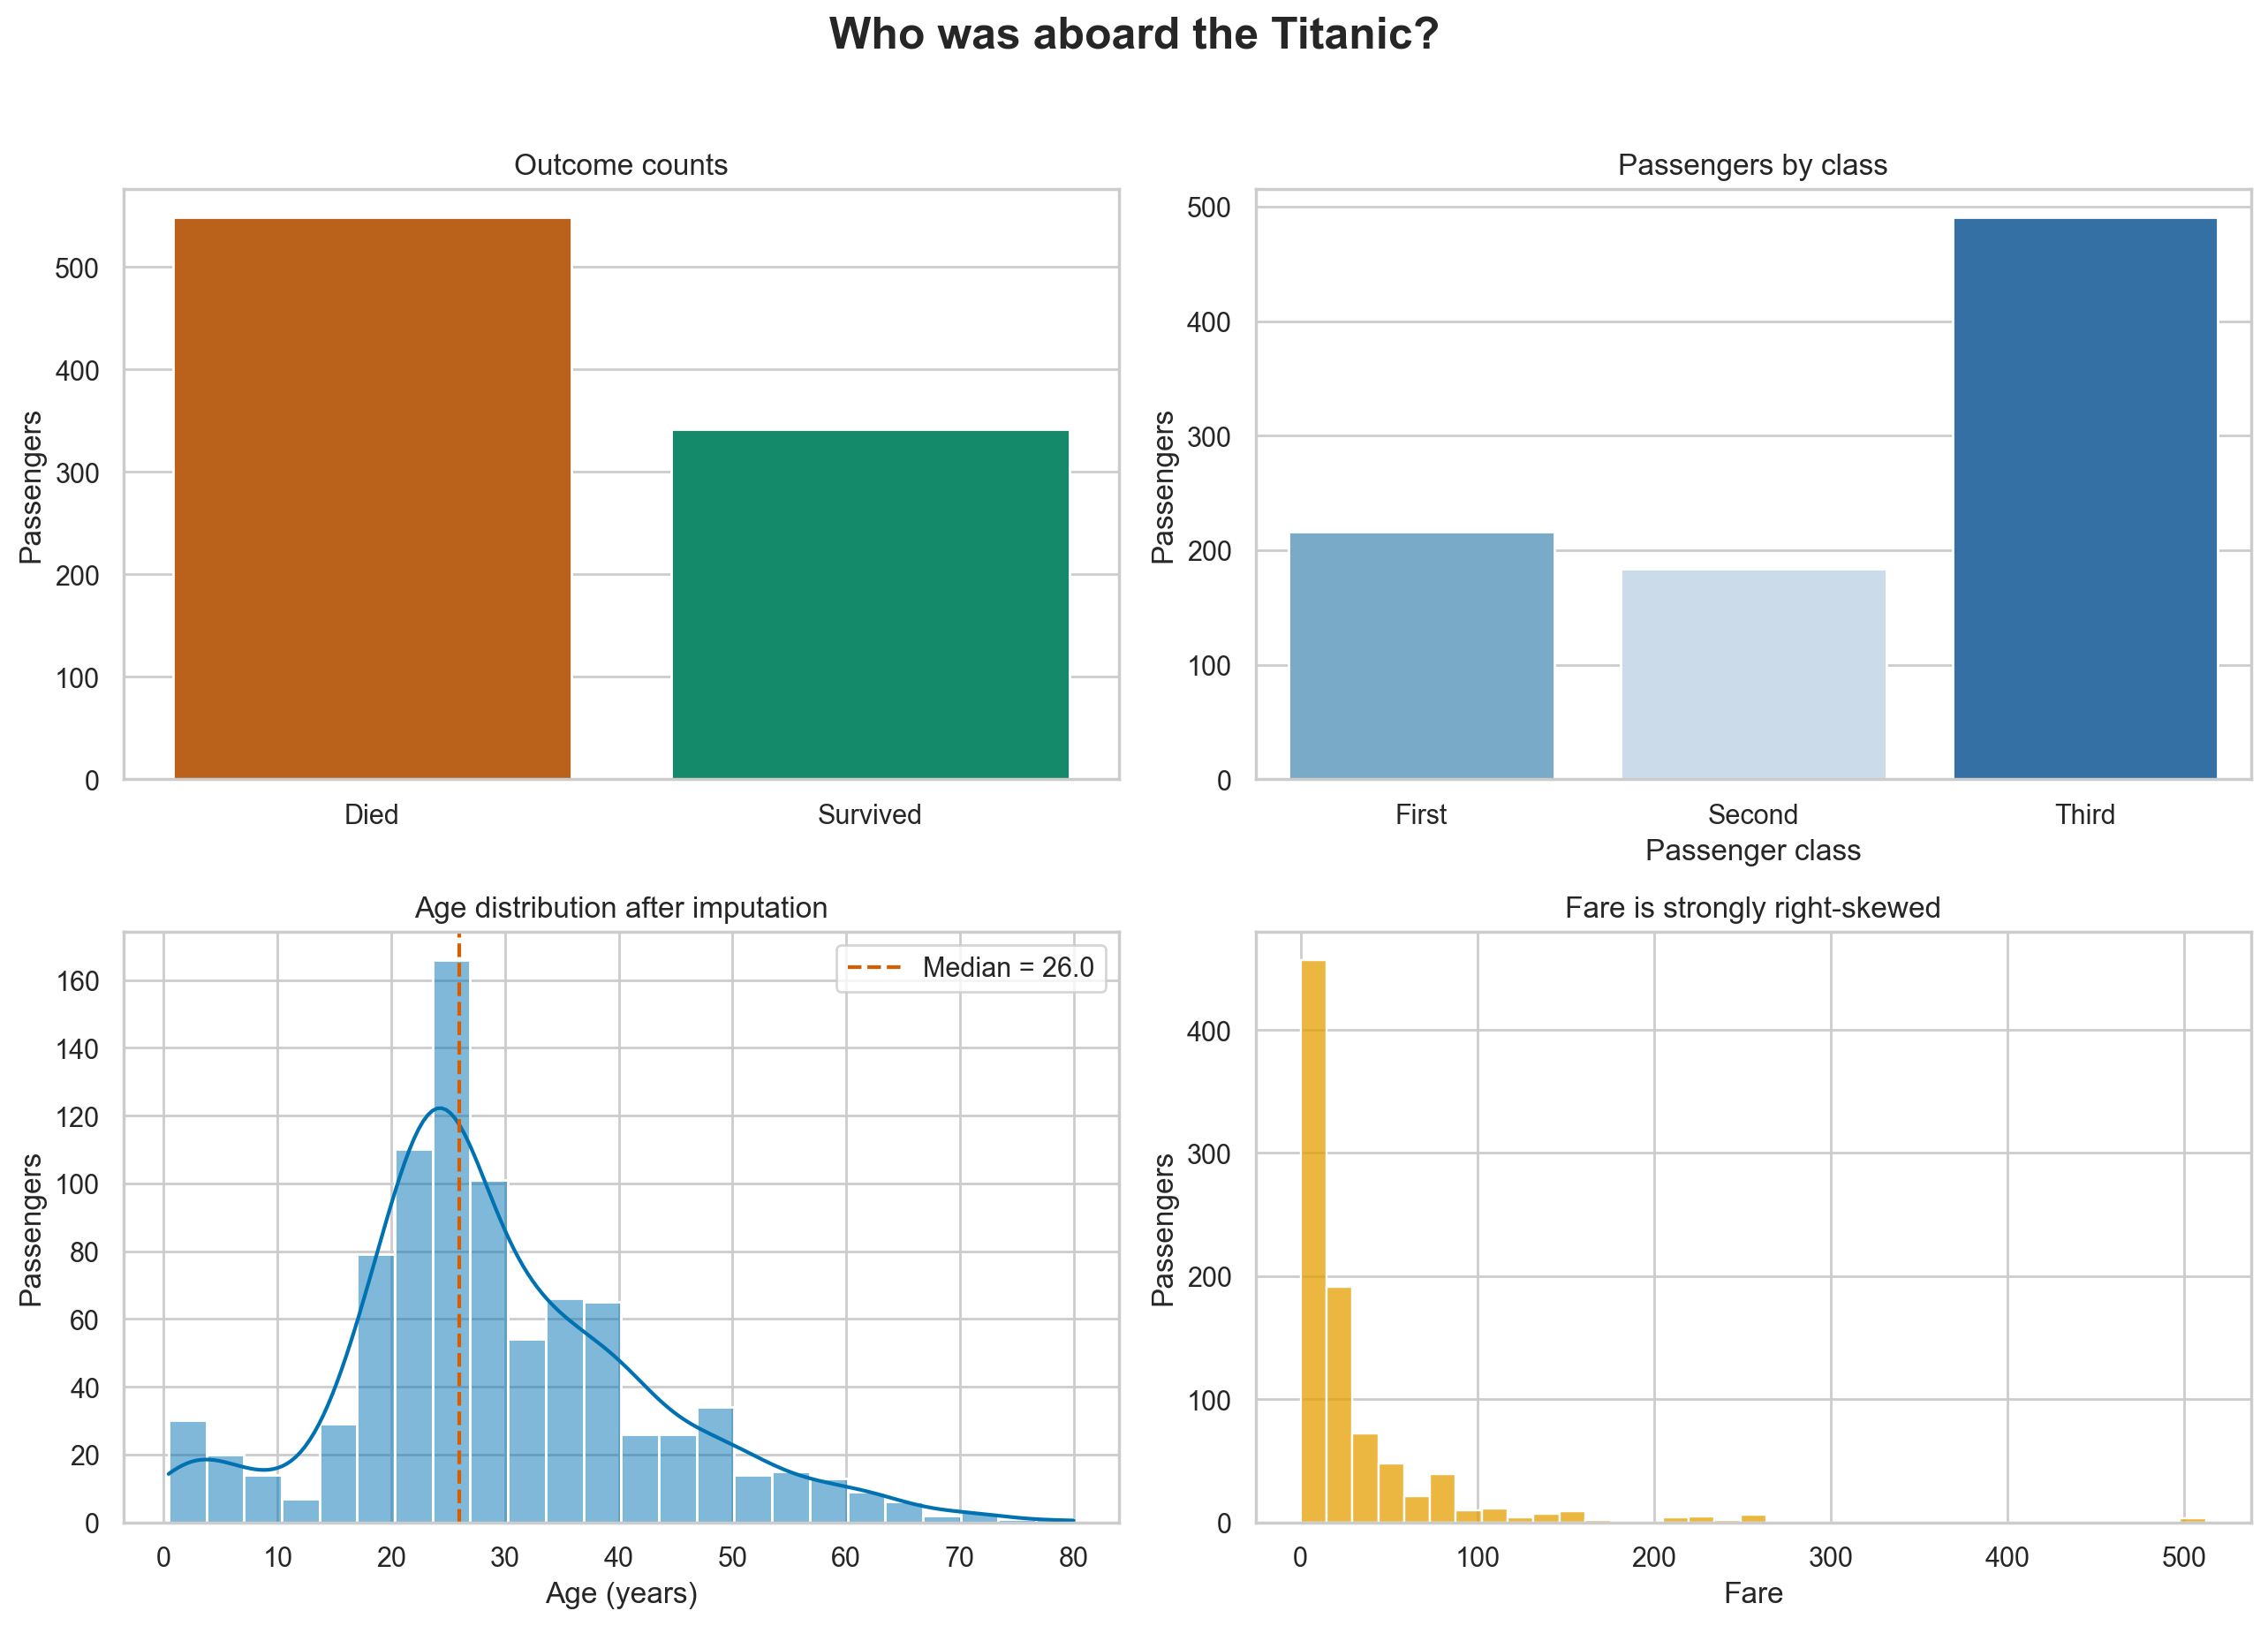

In [14]:
# VISUAL 3 — Four compact views of the passenger population.
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.countplot(data=df, x="survival_label", hue="survival_label", palette=[COLORS["died"], COLORS["survived"]], legend=False, ax=axes[0, 0])
axes[0, 0].set(title="Outcome counts", xlabel="", ylabel="Passengers")

sns.countplot(data=df, x="class", order=CLASS_ORDER, hue="class", palette="Blues_r", legend=False, ax=axes[0, 1])
axes[0, 1].set(title="Passengers by class", xlabel="Passenger class", ylabel="Passengers")

sns.histplot(data=df, x="age", bins=24, kde=True, color=COLORS["primary"], ax=axes[1, 0])
axes[1, 0].axvline(df["age"].median(), color=COLORS["died"], linestyle="--", label=f"Median = {df['age'].median():.1f}")
axes[1, 0].set(title="Age distribution after imputation", xlabel="Age (years)", ylabel="Passengers")
axes[1, 0].legend()

sns.histplot(data=df, x="fare", bins=35, color=COLORS["accent"], ax=axes[1, 1])
axes[1, 1].set(title="Fare is strongly right-skewed", xlabel="Fare", ylabel="Passengers")

fig.suptitle("Who was aboard the Titanic?", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

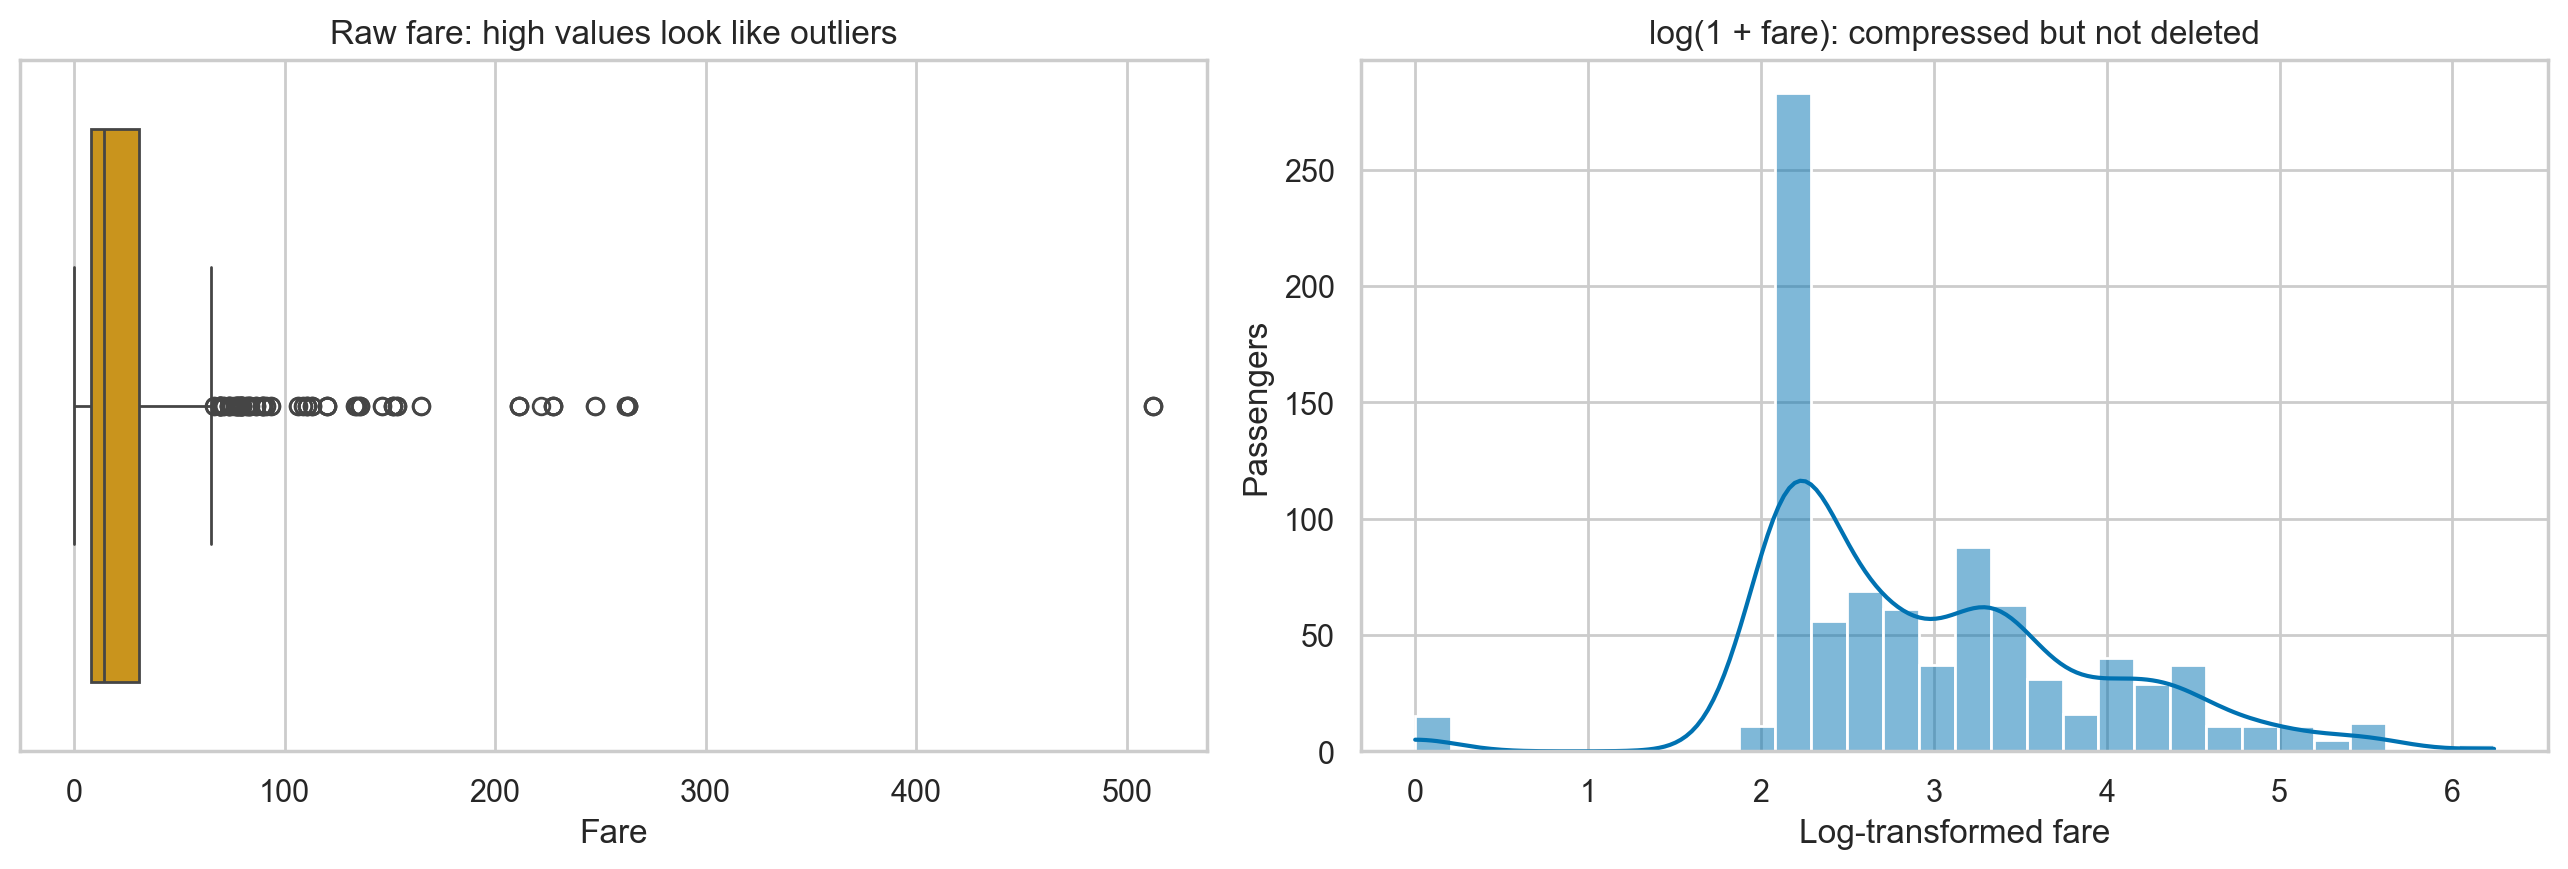

In [15]:
# VISUAL 4 — The same fare data on a log scale reveals the crowded lower range.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=df, x="fare", color=COLORS["accent"], ax=axes[0])
axes[0].set(title="Raw fare: high values look like outliers", xlabel="Fare")

sns.histplot(data=df, x="fare_log", bins=30, kde=True, color=COLORS["primary"], ax=axes[1])
axes[1].set(title="log(1 + fare): compressed but not deleted", xlabel="Log-transformed fare", ylabel="Passengers")

plt.tight_layout()
plt.show()

## 7. Bivariate visualization: compare groups

Now connect a possible explanatory variable to the outcome. These are observational associations—not proof that sex or class *caused* survival.

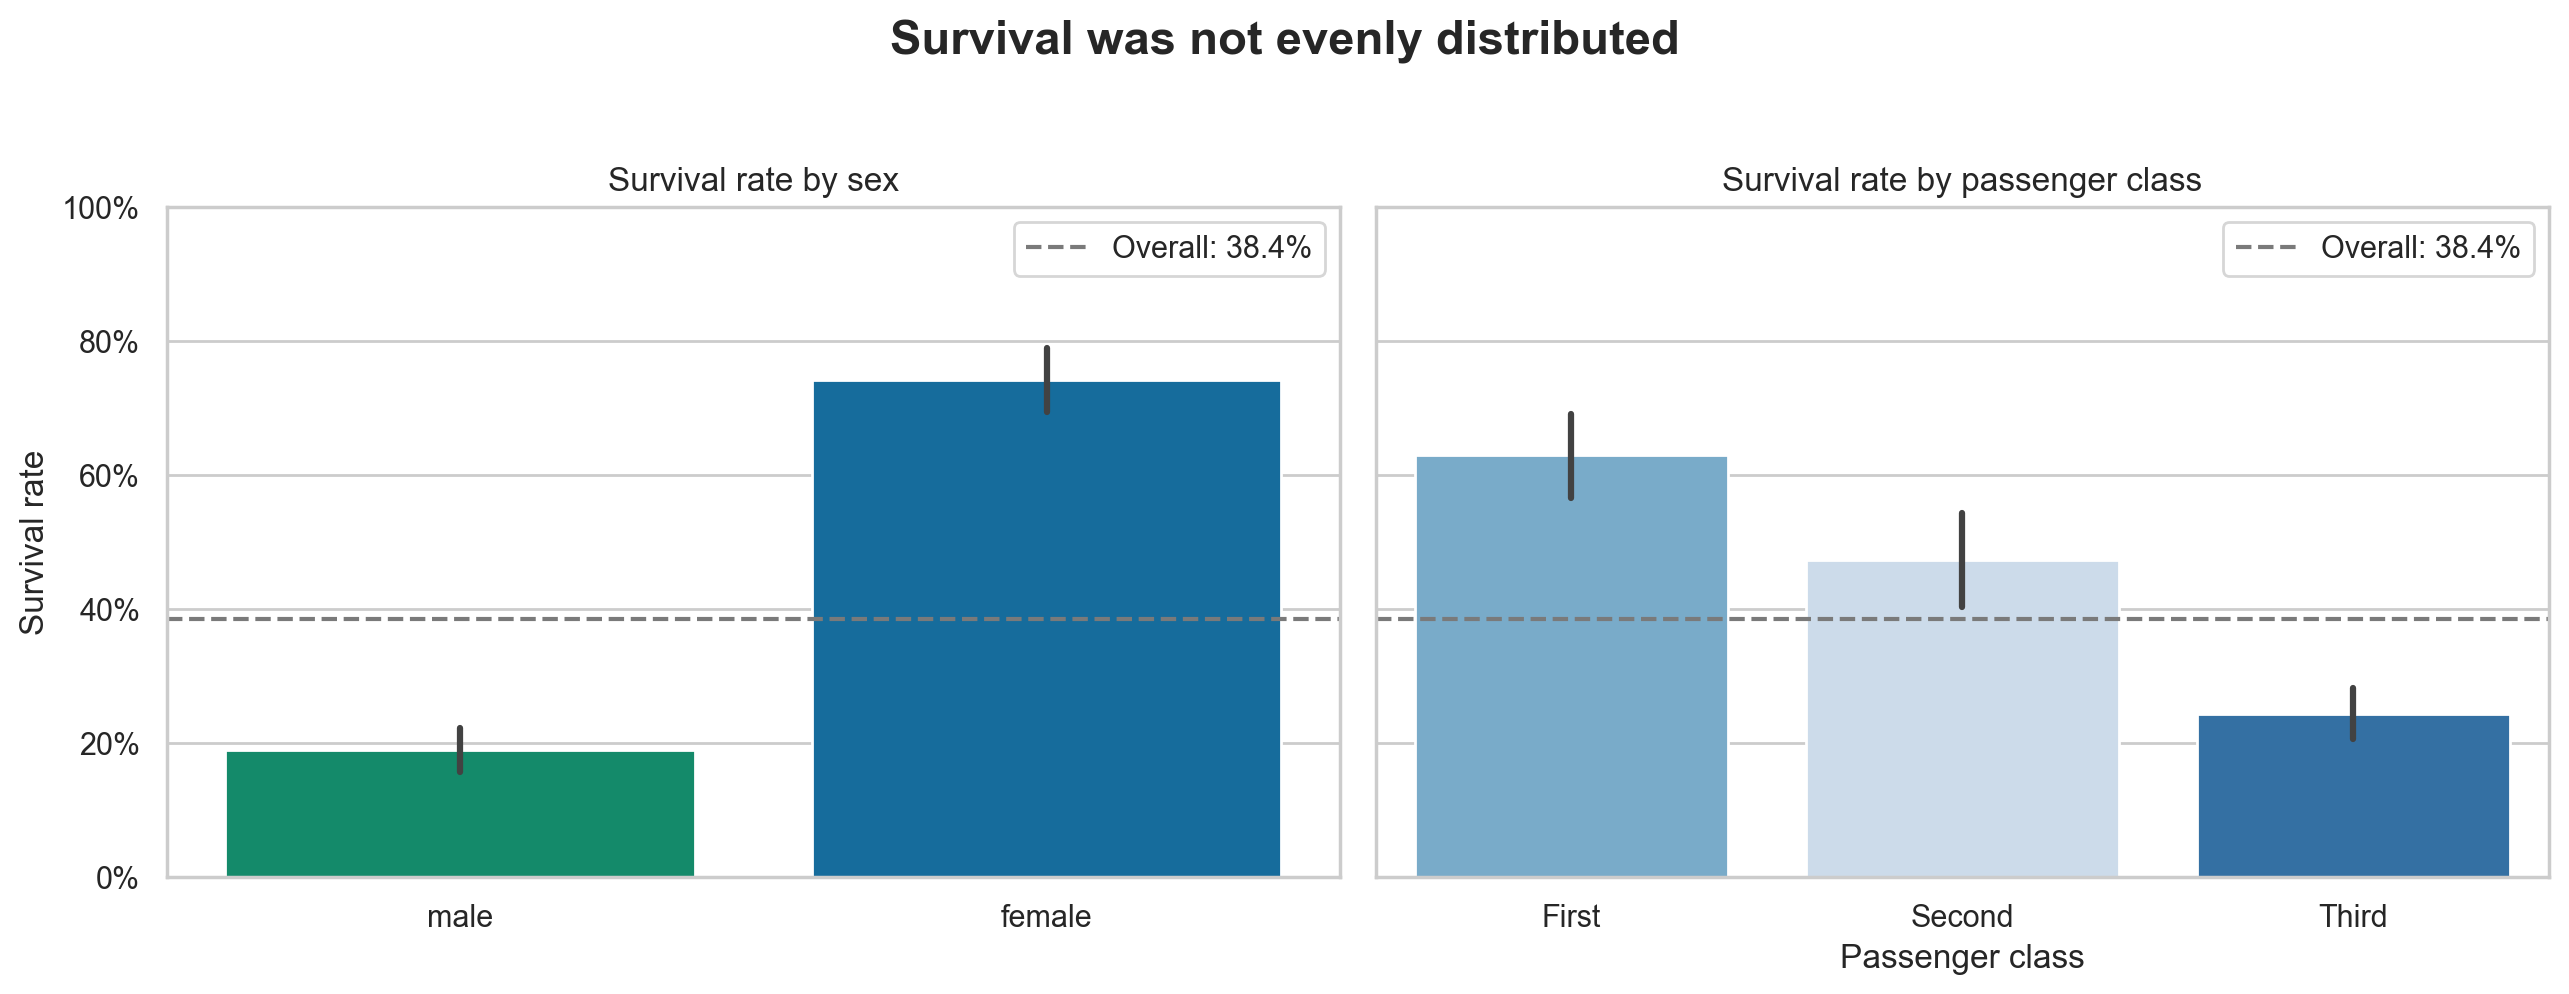

In [16]:
# VISUAL 5 — Survival rate by sex and class, with the overall rate as a reference.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

sns.barplot(data=df, x="sex", y="survived", hue="sex", palette=[COLORS["survived"], COLORS["primary"]], errorbar=("ci", 95), seed=42, legend=False, ax=axes[0])
axes[0].set(title="Survival rate by sex", xlabel="", ylabel="Survival rate")

sns.barplot(data=df, x="class", y="survived", order=CLASS_ORDER, hue="class", palette="Blues_r", errorbar=("ci", 95), seed=42, legend=False, ax=axes[1])
axes[1].set(title="Survival rate by passenger class", xlabel="Passenger class", ylabel="")

for ax in axes:
    ax.axhline(overall_rate, color=COLORS["neutral"], linestyle="--", linewidth=1.5, label=f"Overall: {overall_rate:.1%}")
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_ylim(0, 1)
    ax.legend(loc="upper right")

fig.suptitle("Survival was not evenly distributed", fontsize=17, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

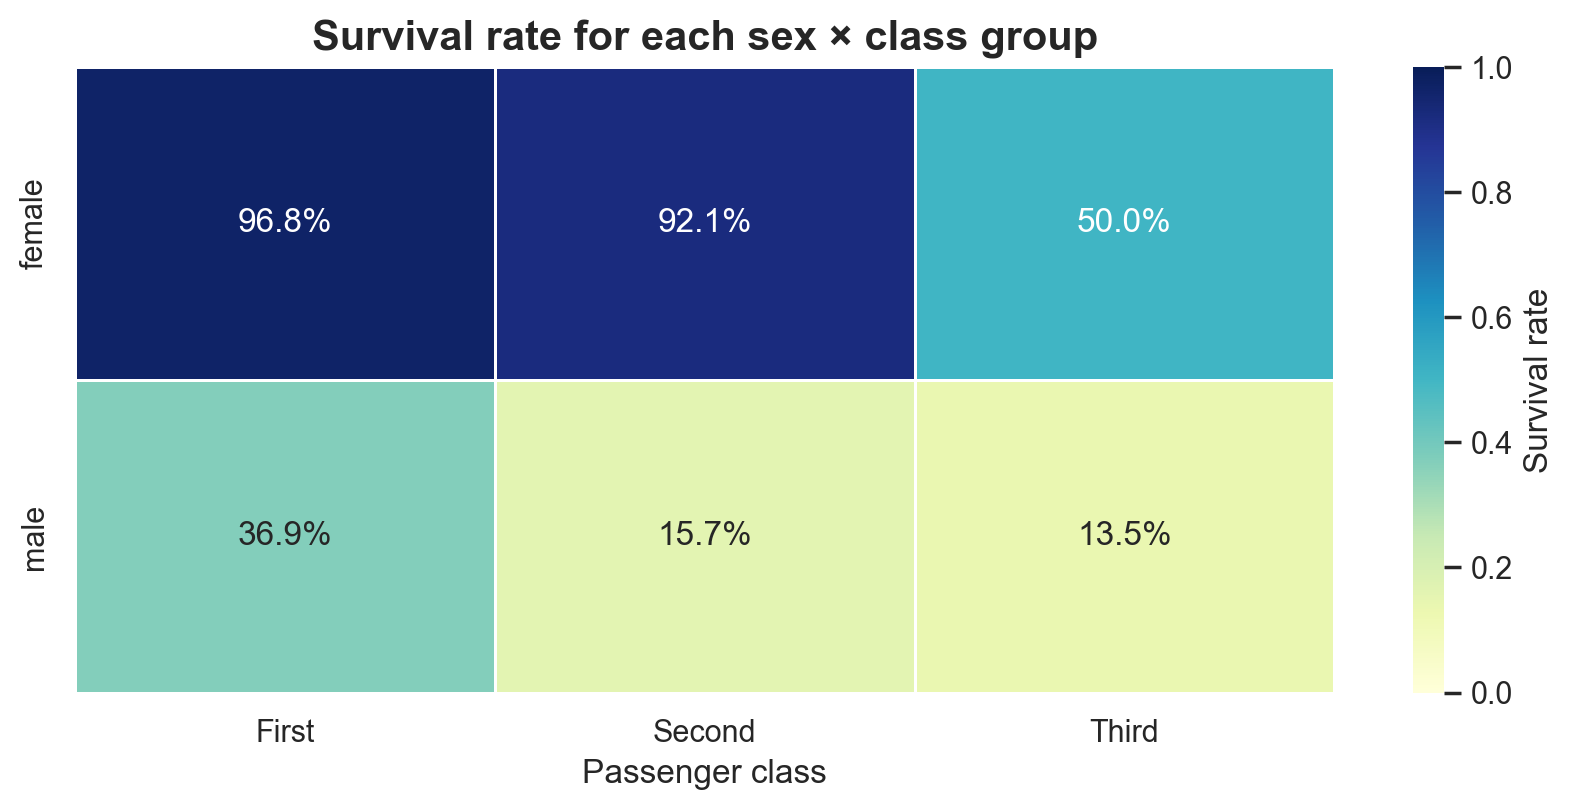

class,First,Second,Third
sex,,,
female,96.8%,92.1%,50.0%
male,36.9%,15.7%,13.5%


In [17]:
# VISUAL 6 — A pivot table becomes a heatmap for two-way comparison.
sex_class_survival = df.pivot_table(
    values="survived",
    index="sex",
    columns="class",
    aggfunc="mean",
    observed=True,
)

plt.figure(figsize=(8.5, 4.2))
sns.heatmap(
    sex_class_survival,
    annot=True,
    fmt=".1%",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=1,
    cbar_kws={"label": "Survival rate"},
)
plt.title("Survival rate for each sex × class group", fontsize=15, fontweight="bold")
plt.xlabel("Passenger class")
plt.ylabel("")
plt.tight_layout()
plt.show()

display(sex_class_survival.style.format("{:.1%}"))

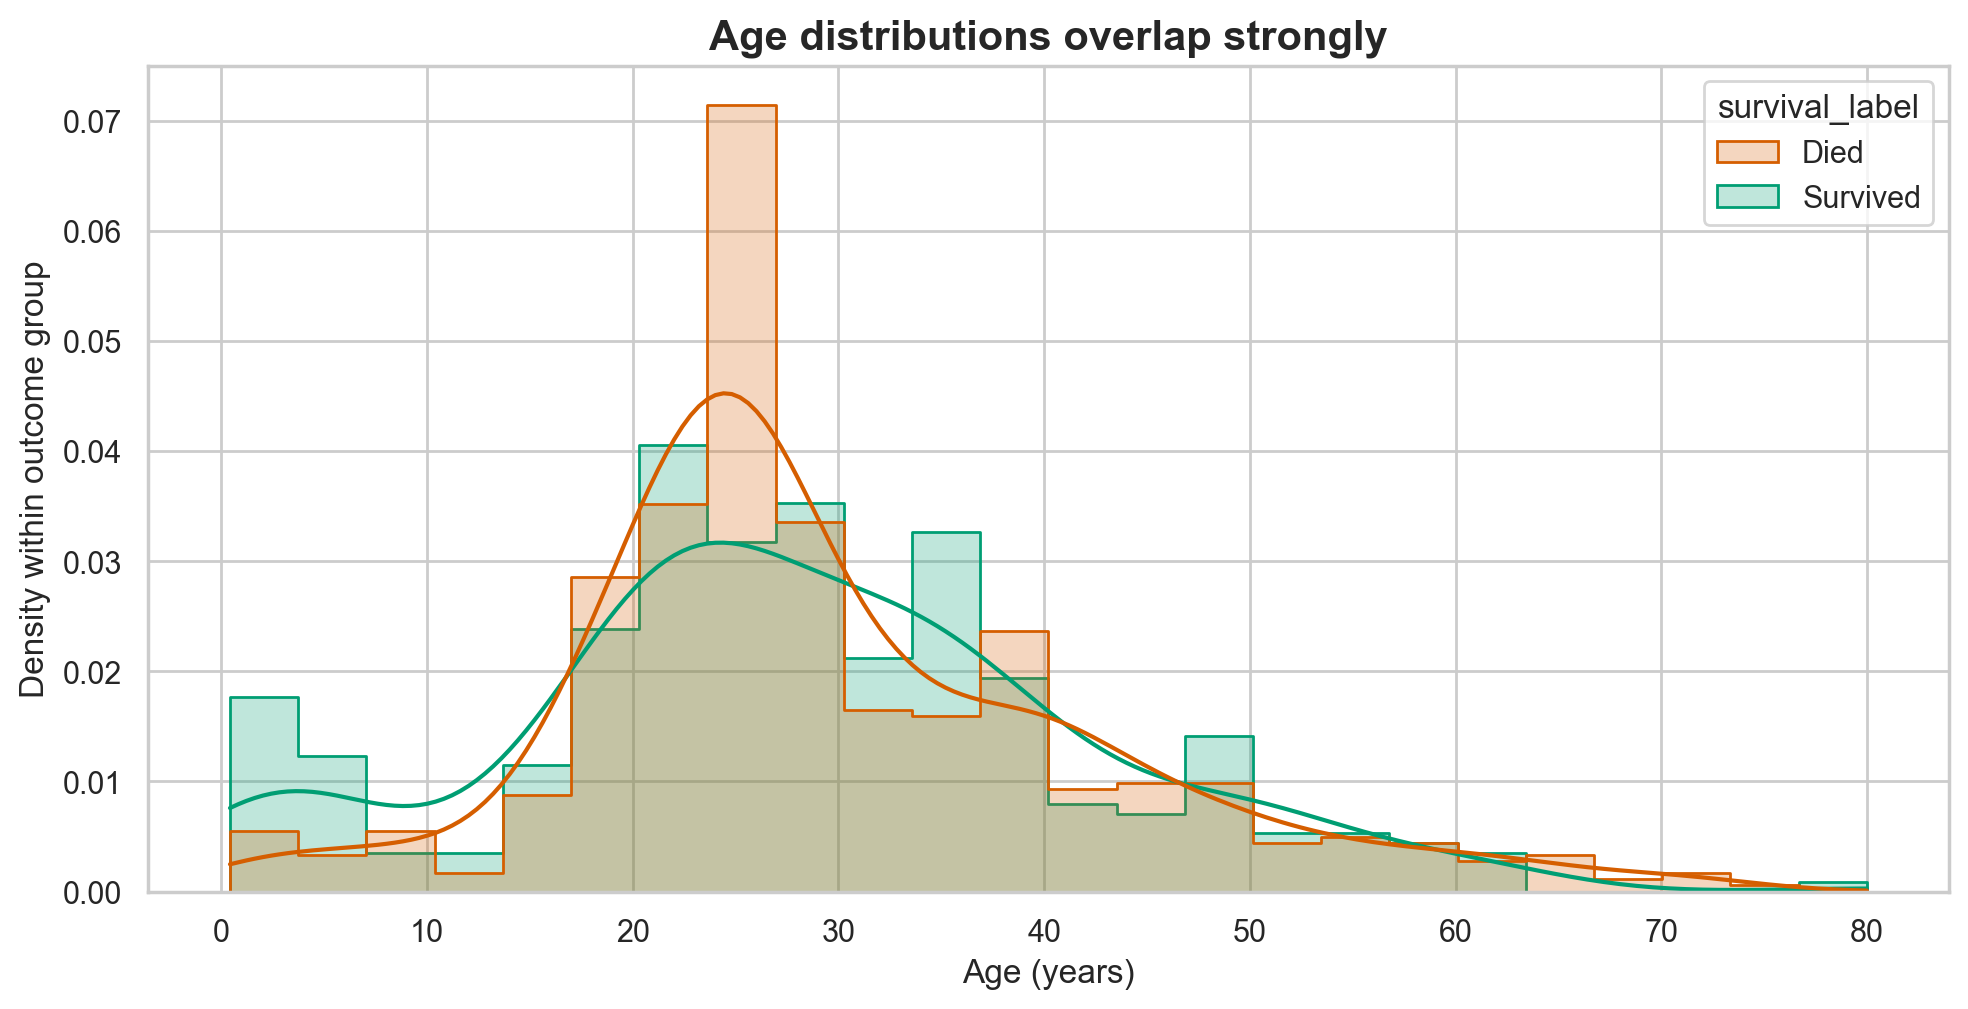

In [18]:
# VISUAL 7 — Compare age distributions, not only average age.
plt.figure(figsize=(10, 5.2))
sns.histplot(
    data=df,
    x="age",
    hue="survival_label",
    hue_order=["Died", "Survived"],
    palette=[COLORS["died"], COLORS["survived"]],
    bins=24,
    stat="density",
    common_norm=False,
    element="step",
    kde=True,
    alpha=0.25,
)
plt.title("Age distributions overlap strongly", fontsize=15, fontweight="bold")
plt.xlabel("Age (years)")
plt.ylabel("Density within outcome group")
plt.tight_layout()
plt.show()

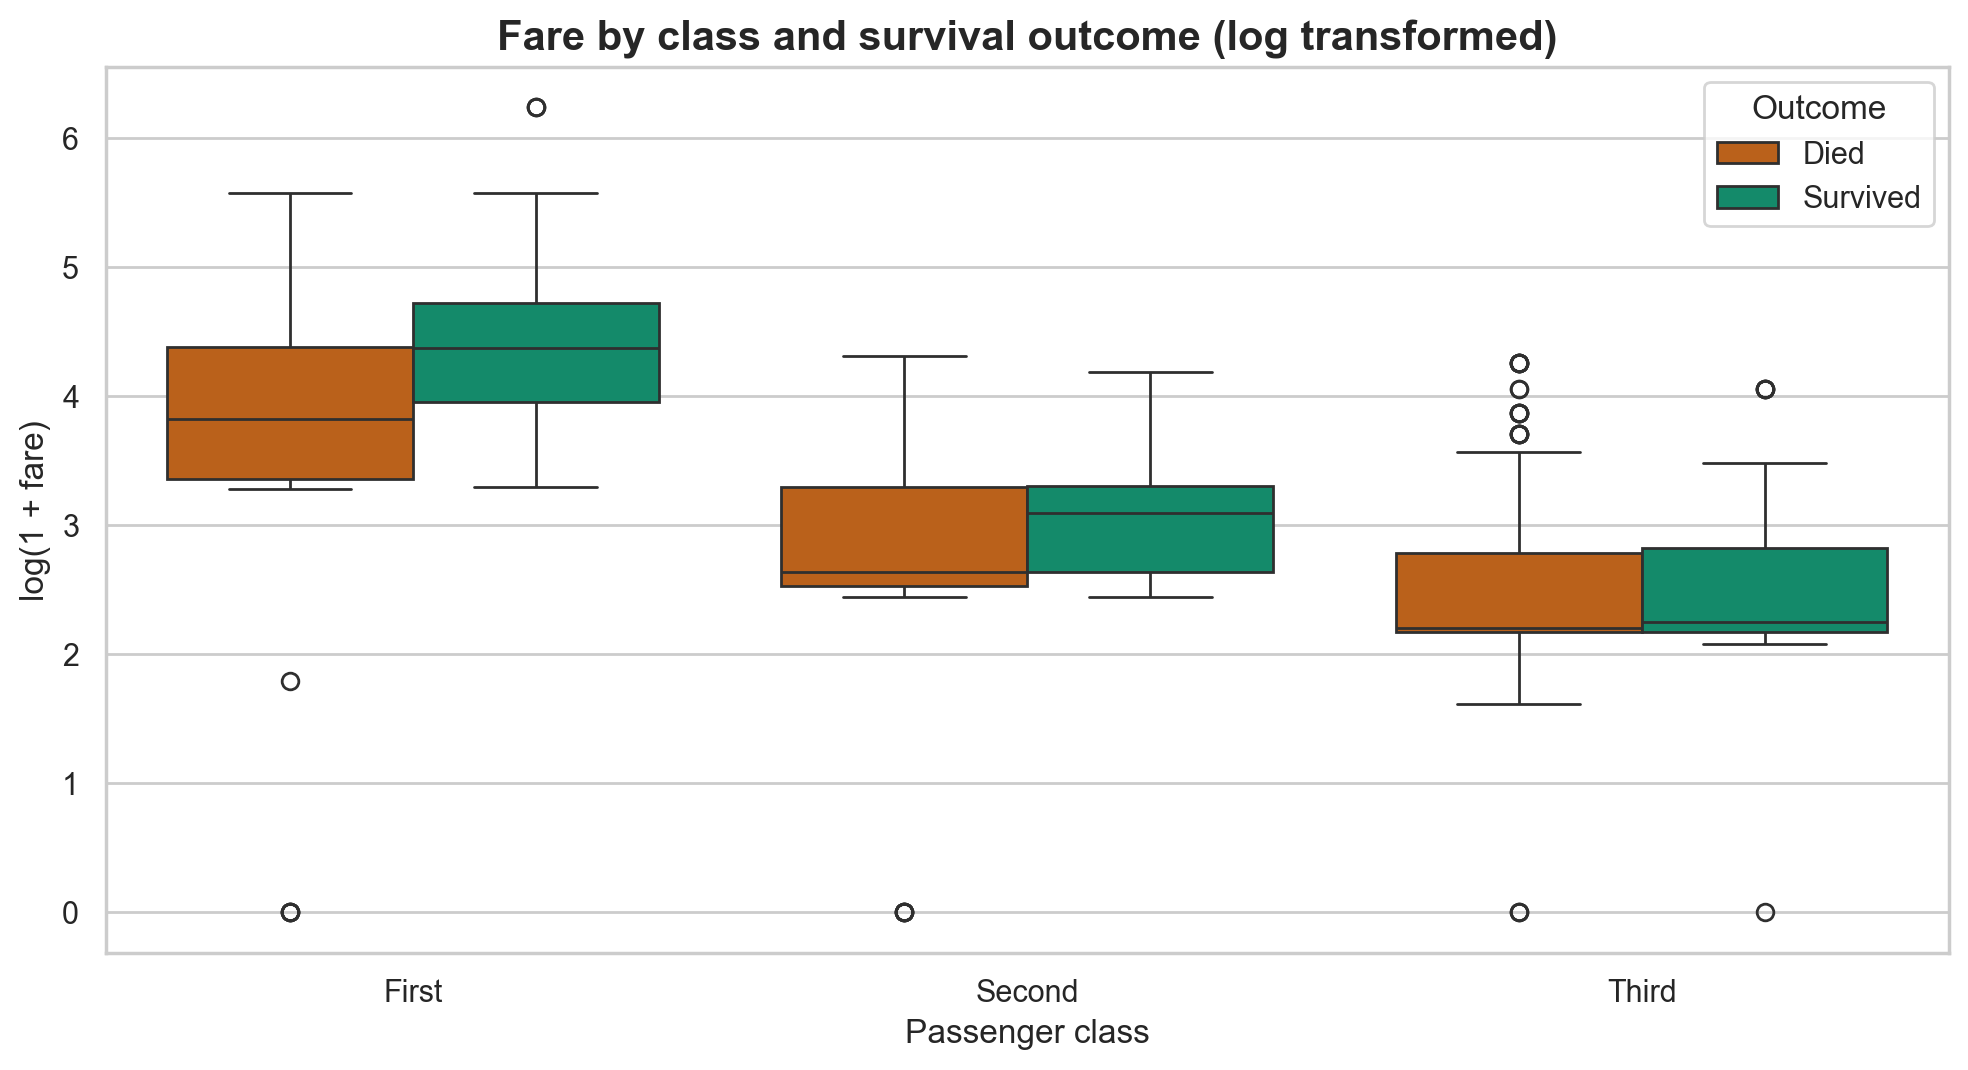

In [19]:
# VISUAL 8 — Boxplots show median, middle 50%, and outliers together.
plt.figure(figsize=(10, 5.5))
sns.boxplot(
    data=df,
    x="class",
    order=CLASS_ORDER,
    y="fare_log",
    hue="survival_label",
    hue_order=["Died", "Survived"],
    palette=[COLORS["died"], COLORS["survived"]],
)
plt.title("Fare by class and survival outcome (log transformed)", fontsize=15, fontweight="bold")
plt.xlabel("Passenger class")
plt.ylabel("log(1 + fare)")
plt.legend(title="Outcome")
plt.tight_layout()
plt.show()

## 8. Engineered features reveal additional patterns

Raw `sibsp` and `parch` counts are hard to interpret separately. `family_size` combines them and adds the passenger. Group sizes with very few passengers should be interpreted cautiously.

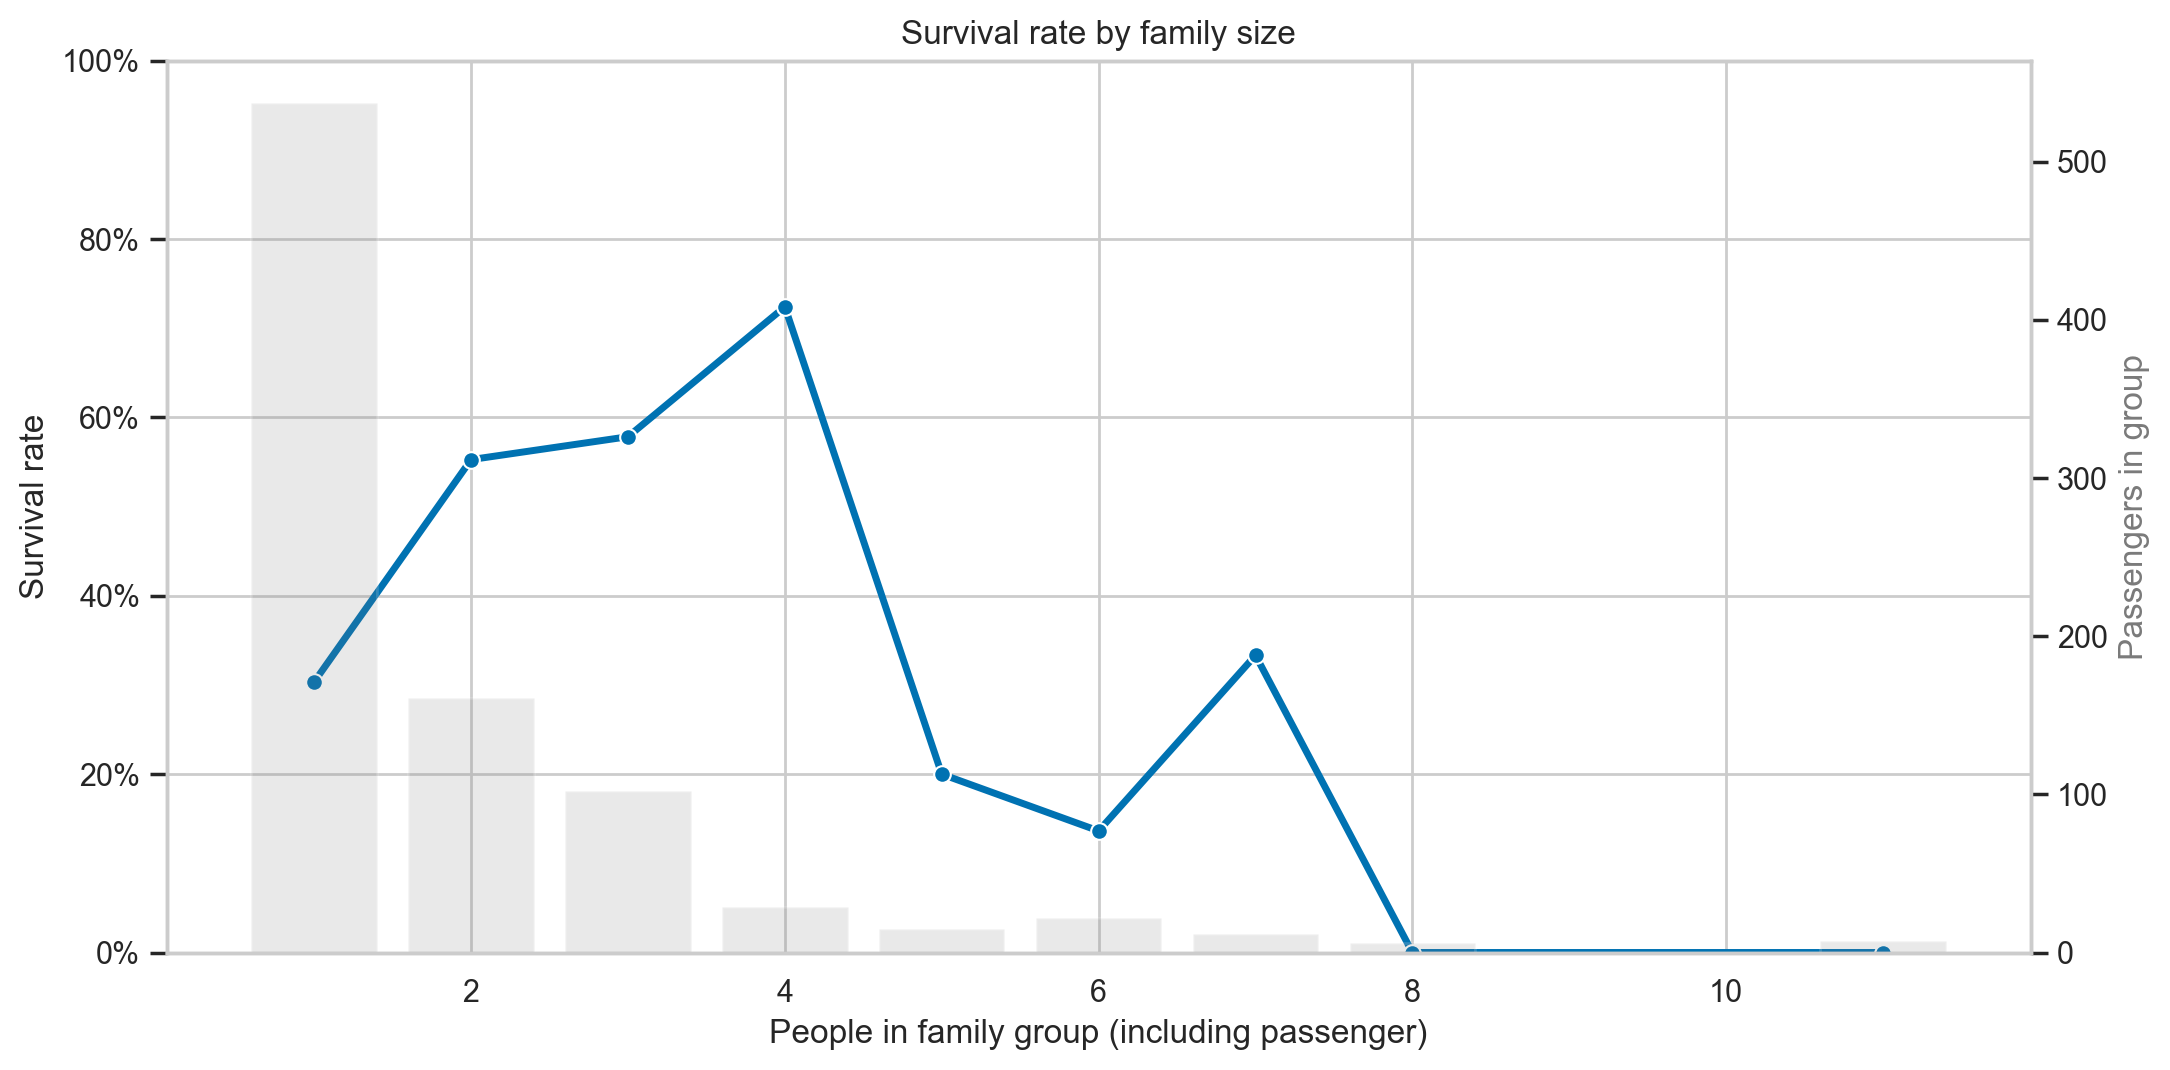

,family_size,survival_rate,passengers
0,1,30.4%,537
1,2,55.3%,161
2,3,57.8%,102
3,4,72.4%,29
4,5,20.0%,15
5,6,13.6%,22
6,7,33.3%,12
7,8,0.0%,6
8,11,0.0%,7


In [20]:
family_summary = (
    df.groupby("family_size", observed=True)["survived"]
    .agg(survival_rate="mean", passengers="size")
    .reset_index()
)

# VISUAL 9 — Rate and sample size belong together.
fig, ax1 = plt.subplots(figsize=(11, 5.5))
sns.lineplot(data=family_summary, x="family_size", y="survival_rate", marker="o", linewidth=2.5, color=COLORS["primary"], ax=ax1)
ax1.set(title="Survival rate by family size", xlabel="People in family group (including passenger)", ylabel="Survival rate")
ax1.yaxis.set_major_formatter(PercentFormatter(1))
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.bar(family_summary["family_size"], family_summary["passengers"], alpha=0.16, color=COLORS["neutral"], label="Passenger count")
ax2.set_ylabel("Passengers in group", color=COLORS["neutral"])
ax2.grid(False)

plt.tight_layout()
plt.show()
display(family_summary.style.format({"survival_rate": "{:.1%}", "passengers": "{:,.0f}"}))

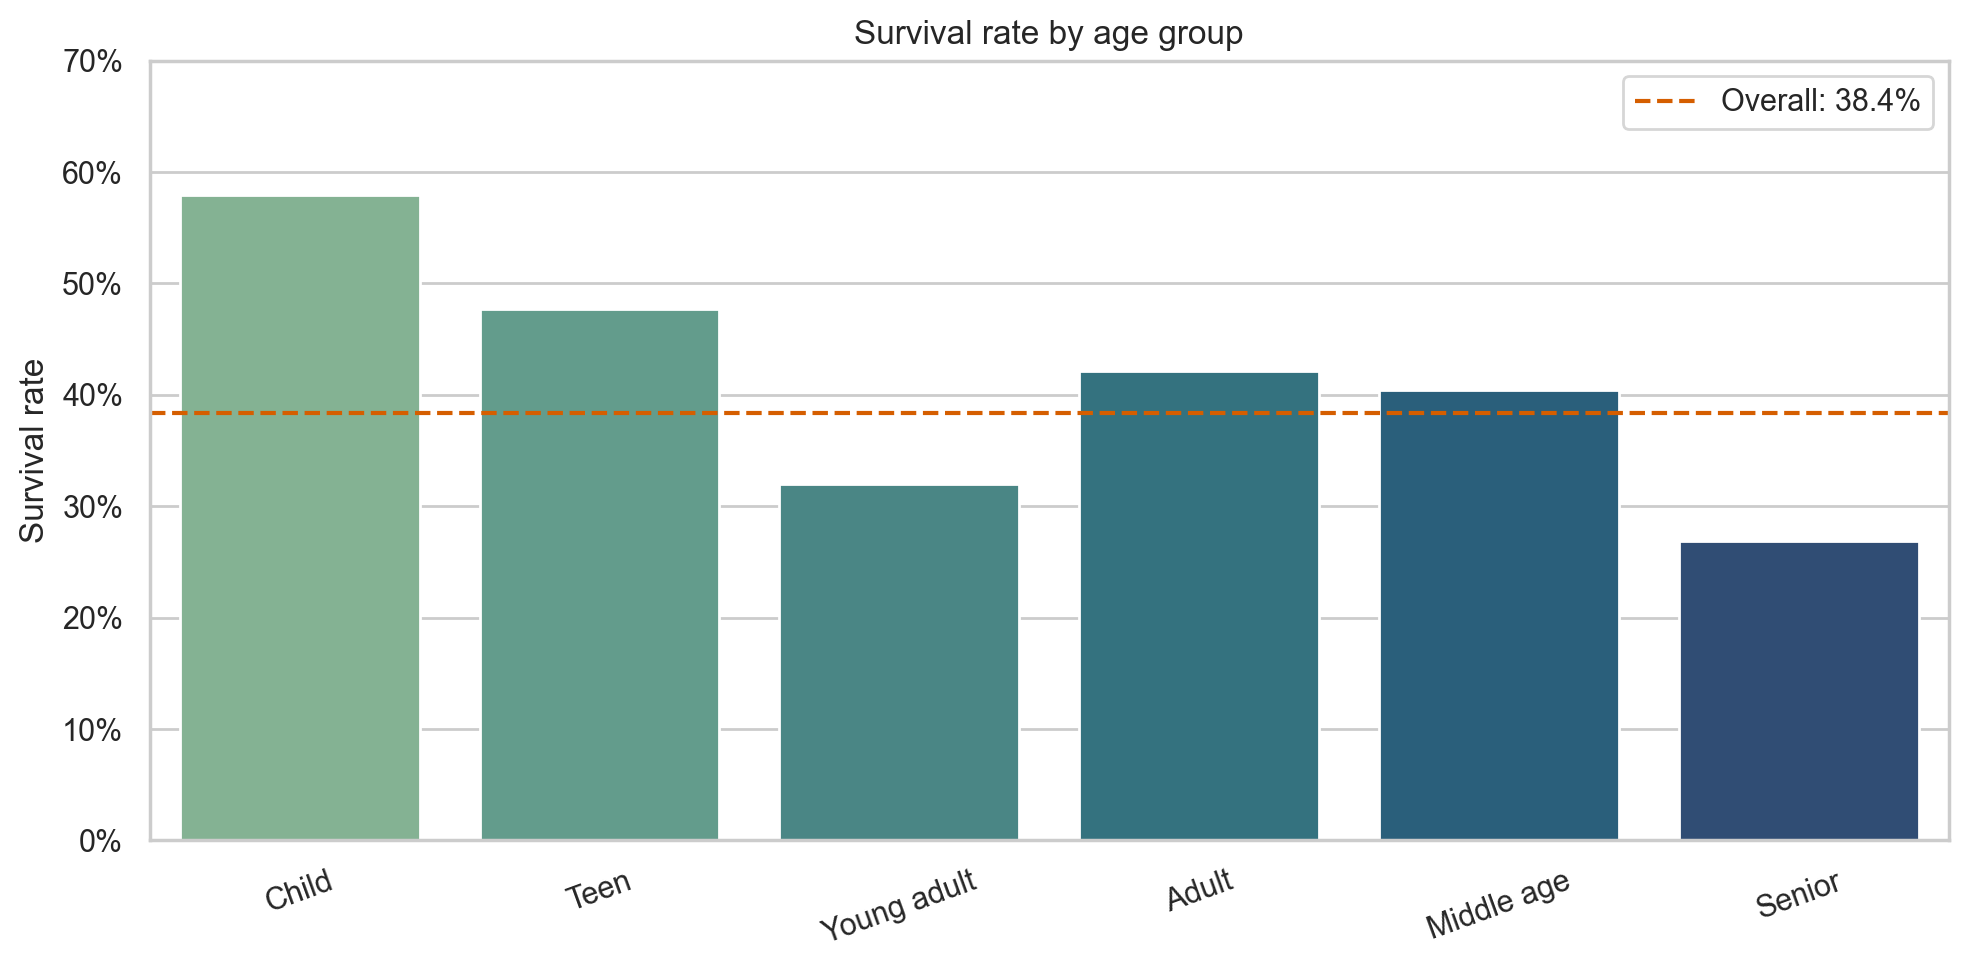

In [21]:
age_group_summary = (
    df.groupby("age_group", observed=True)["survived"]
    .agg(survival_rate="mean", passengers="size")
    .reset_index()
)

# VISUAL 10 — Ordered age bands are easier to compare than 891 individual ages.
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=age_group_summary, x="age_group", y="survival_rate", hue="age_group", palette="crest", legend=False, ax=ax)
ax.axhline(overall_rate, color=COLORS["died"], linestyle="--", label=f"Overall: {overall_rate:.1%}")
ax.set(title="Survival rate by age group", xlabel="", ylabel="Survival rate", ylim=(0, 0.7))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.tick_params(axis="x", rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

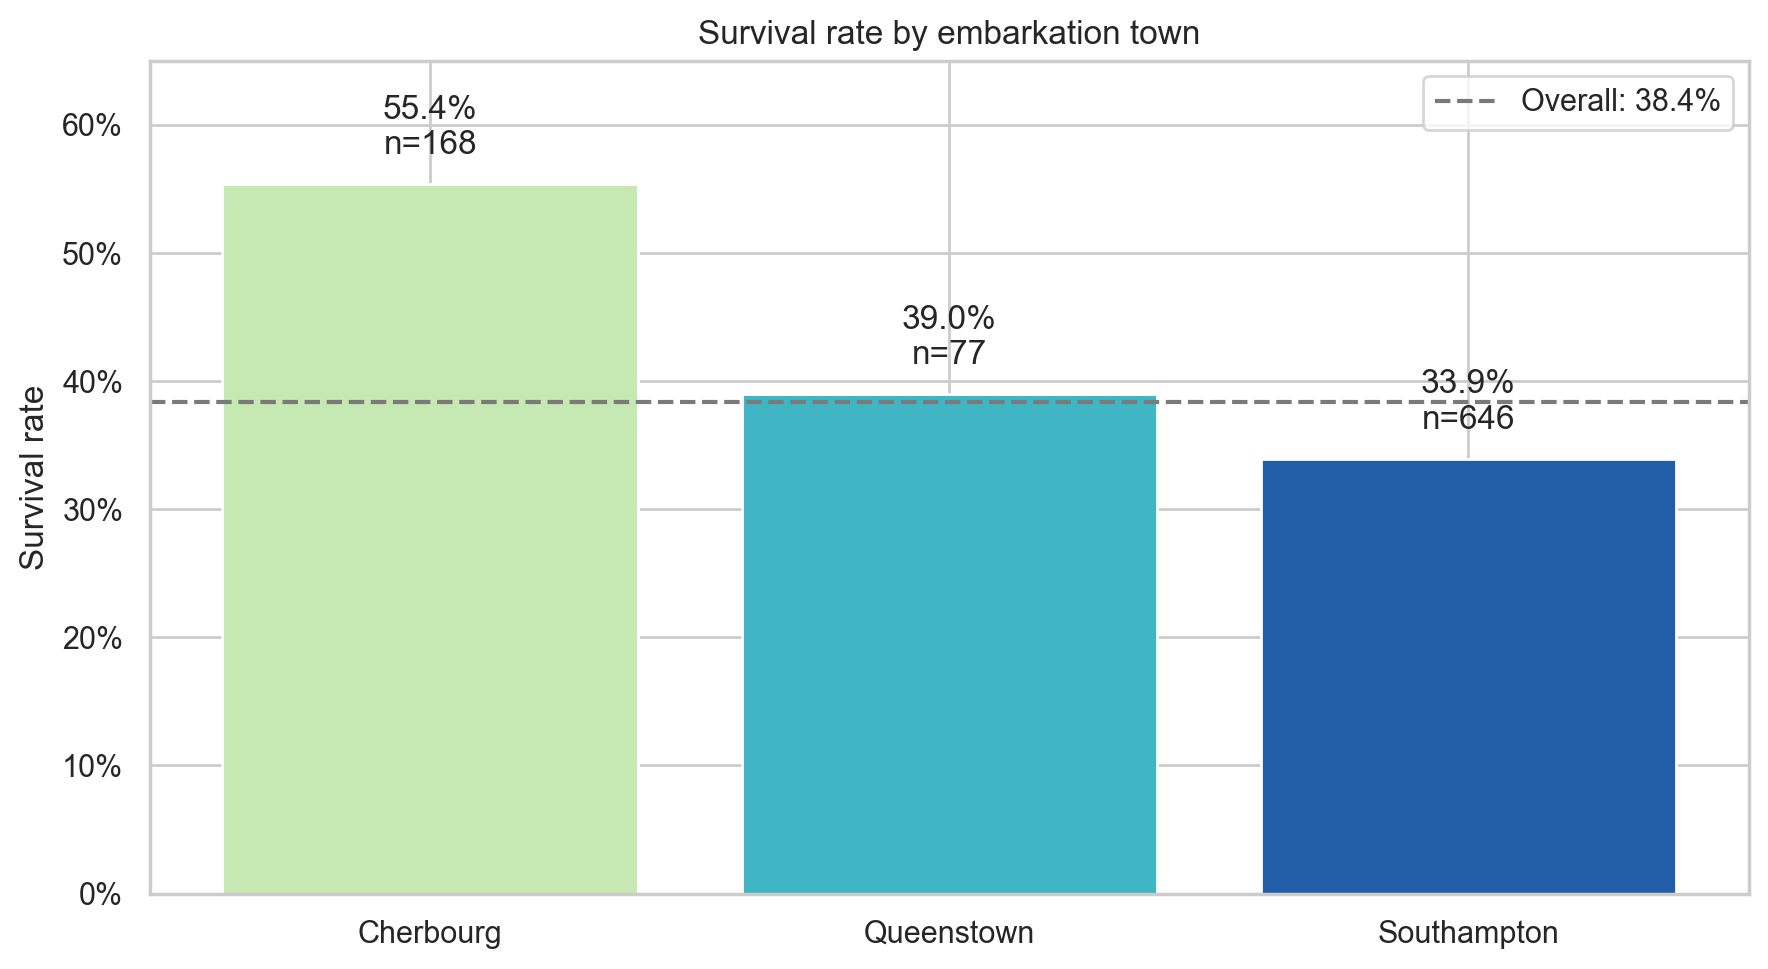

In [22]:
# VISUAL 11 — Port-level comparison. Bars show estimates; labels show group size.
embark_summary = (
    df.groupby("embark_town", observed=True)["survived"]
    .agg(survival_rate="mean", passengers="size")
    .sort_values("survival_rate", ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(embark_summary["embark_town"], embark_summary["survival_rate"], color=sns.color_palette("YlGnBu", 3))
for bar, passengers, rate in zip(bars, embark_summary["passengers"], embark_summary["survival_rate"]):
    ax.text(bar.get_x() + bar.get_width()/2, rate + 0.018, f"{rate:.1%}\nn={passengers}", ha="center", va="bottom")
ax.axhline(overall_rate, color=COLORS["neutral"], linestyle="--", label=f"Overall: {overall_rate:.1%}")
ax.set(title="Survival rate by embarkation town", xlabel="", ylabel="Survival rate", ylim=(0, 0.65))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend()
plt.tight_layout()
plt.show()

## 9. Multivariate relationships and correlation

Correlation measures **linear association**, from -1 to +1. It does not establish causation, and redundant encodings such as `pclass`/`class` or `survived`/`alive` should not both be included.

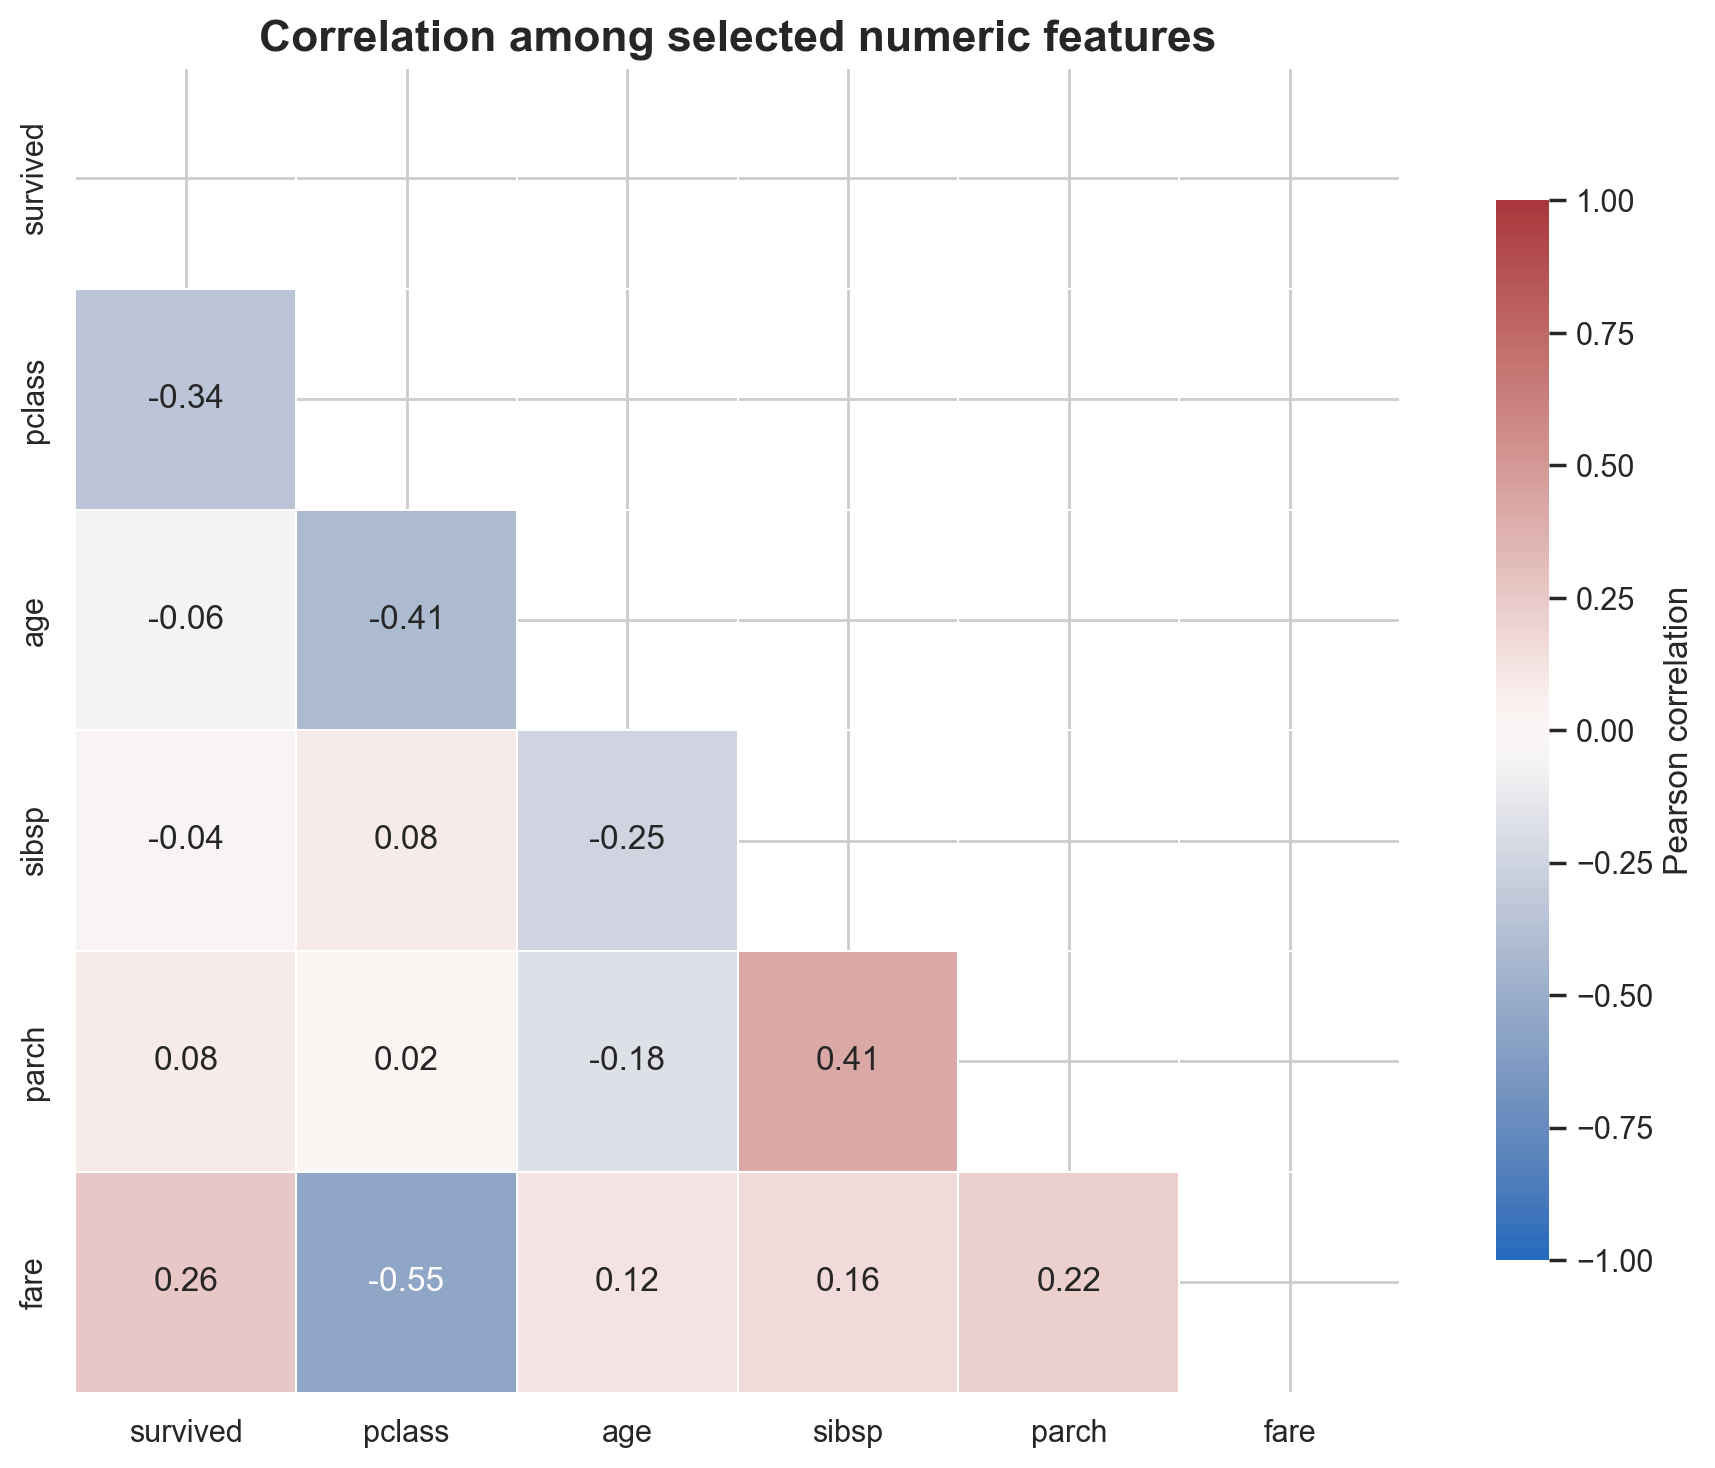

In [23]:
numeric_columns = [
    "survived", "pclass", "age", "sibsp", "parch", "fare"
]
corr = df[numeric_columns].corr()

# VISUAL 12 — Mask the duplicate half so attention stays on unique relationships.
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 7.5))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.6,
    cbar_kws={"shrink": 0.8, "label": "Pearson correlation"},
)
plt.title("Correlation among selected numeric features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

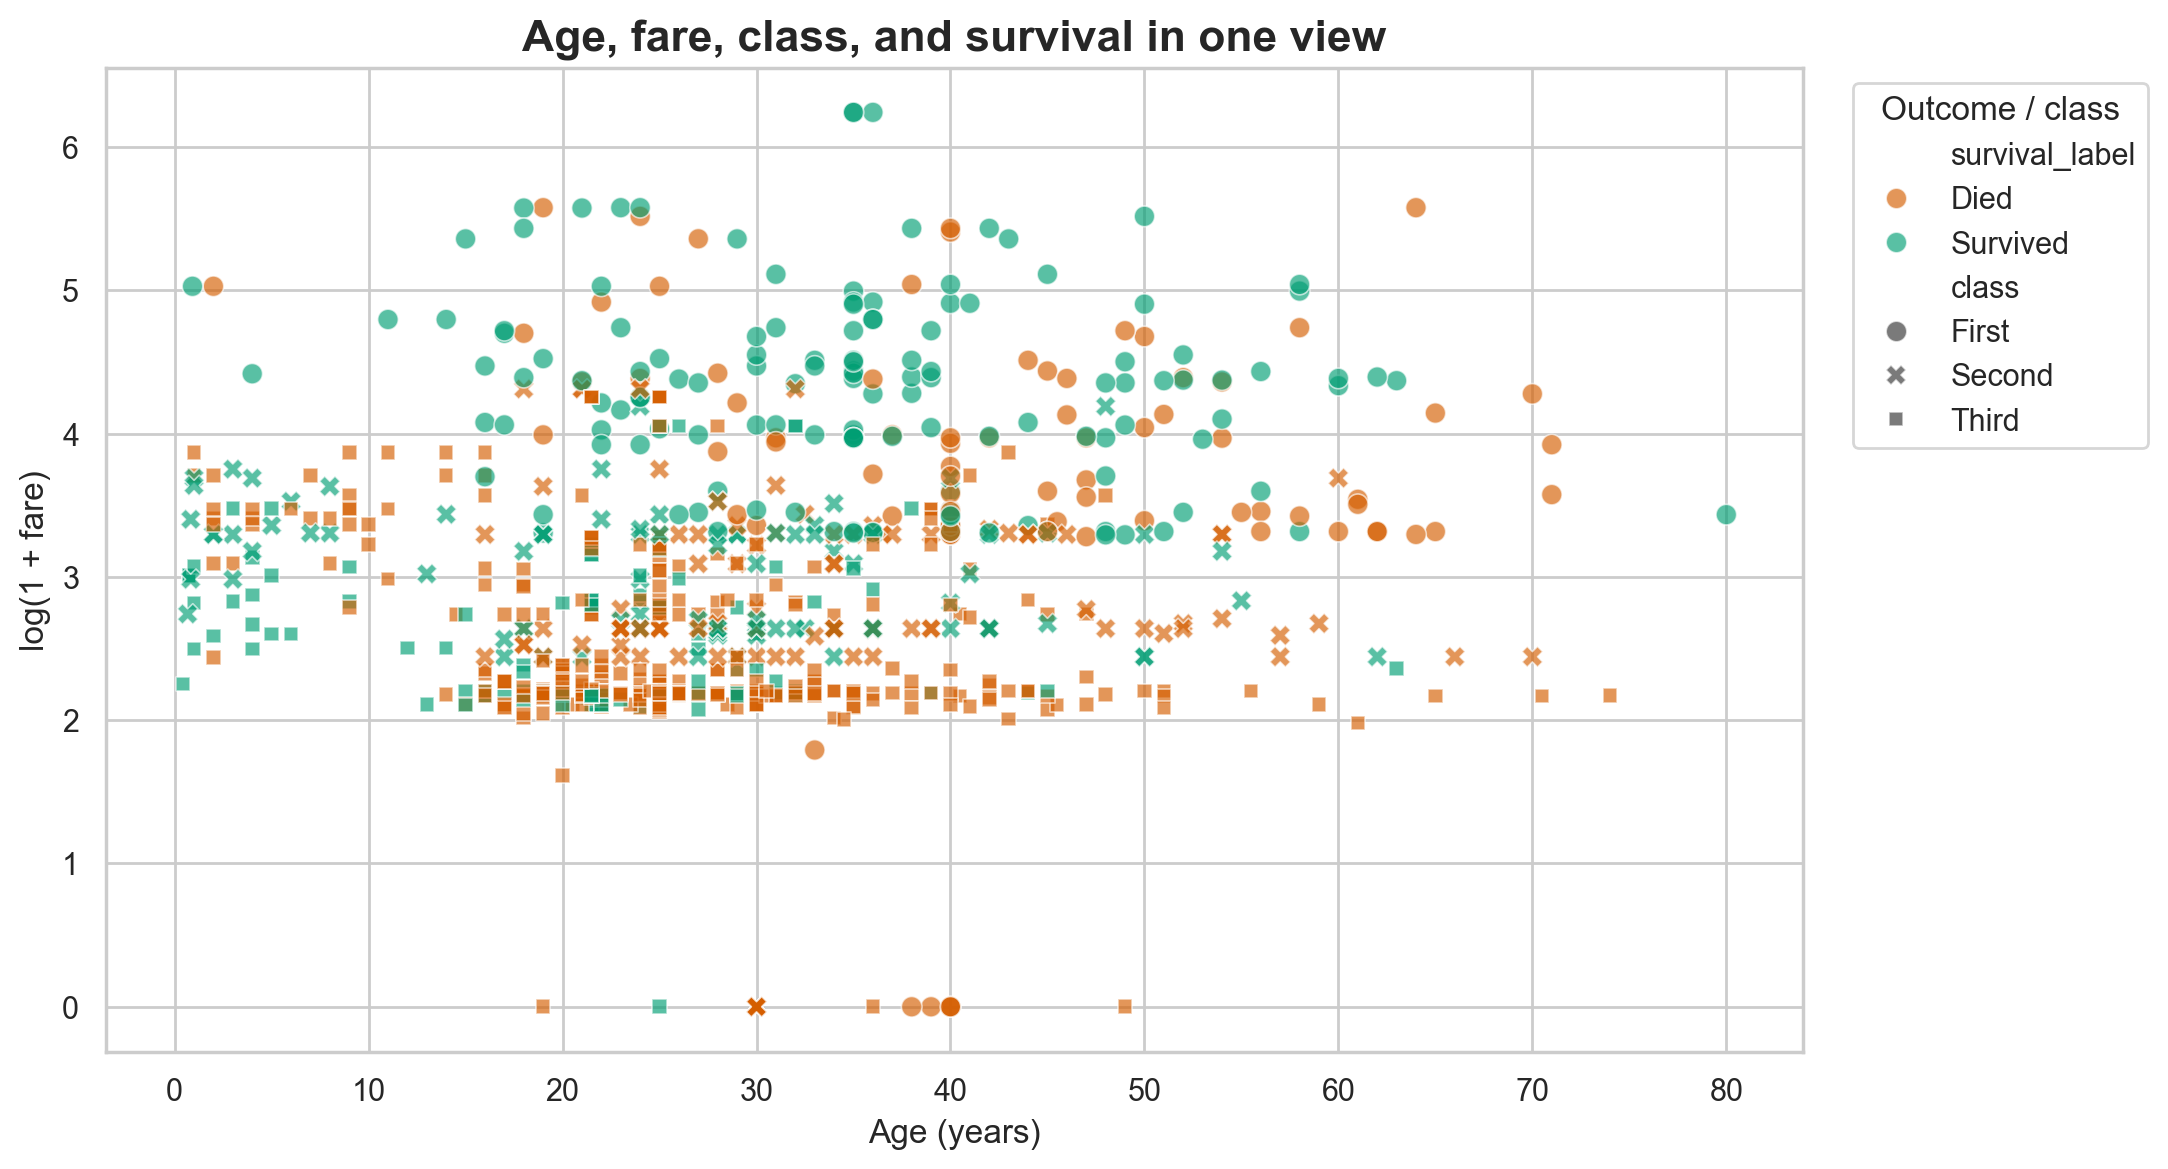

In [24]:
# VISUAL 13 — Each point is one passenger; transparency reveals crowded regions.
plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=df,
    x="age",
    y="fare_log",
    hue="survival_label",
    hue_order=["Died", "Survived"],
    style="class",
    style_order=CLASS_ORDER,
    palette=[COLORS["died"], COLORS["survived"]],
    alpha=0.65,
    s=55,
)
plt.title("Age, fare, class, and survival in one view", fontsize=16, fontweight="bold")
plt.xlabel("Age (years)")
plt.ylabel("log(1 + fare)")
plt.legend(title="Outcome / class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 10. Final EDA dashboard

A useful report does not include every chart you can make. It selects a small set of views that support the main story and labels them clearly.

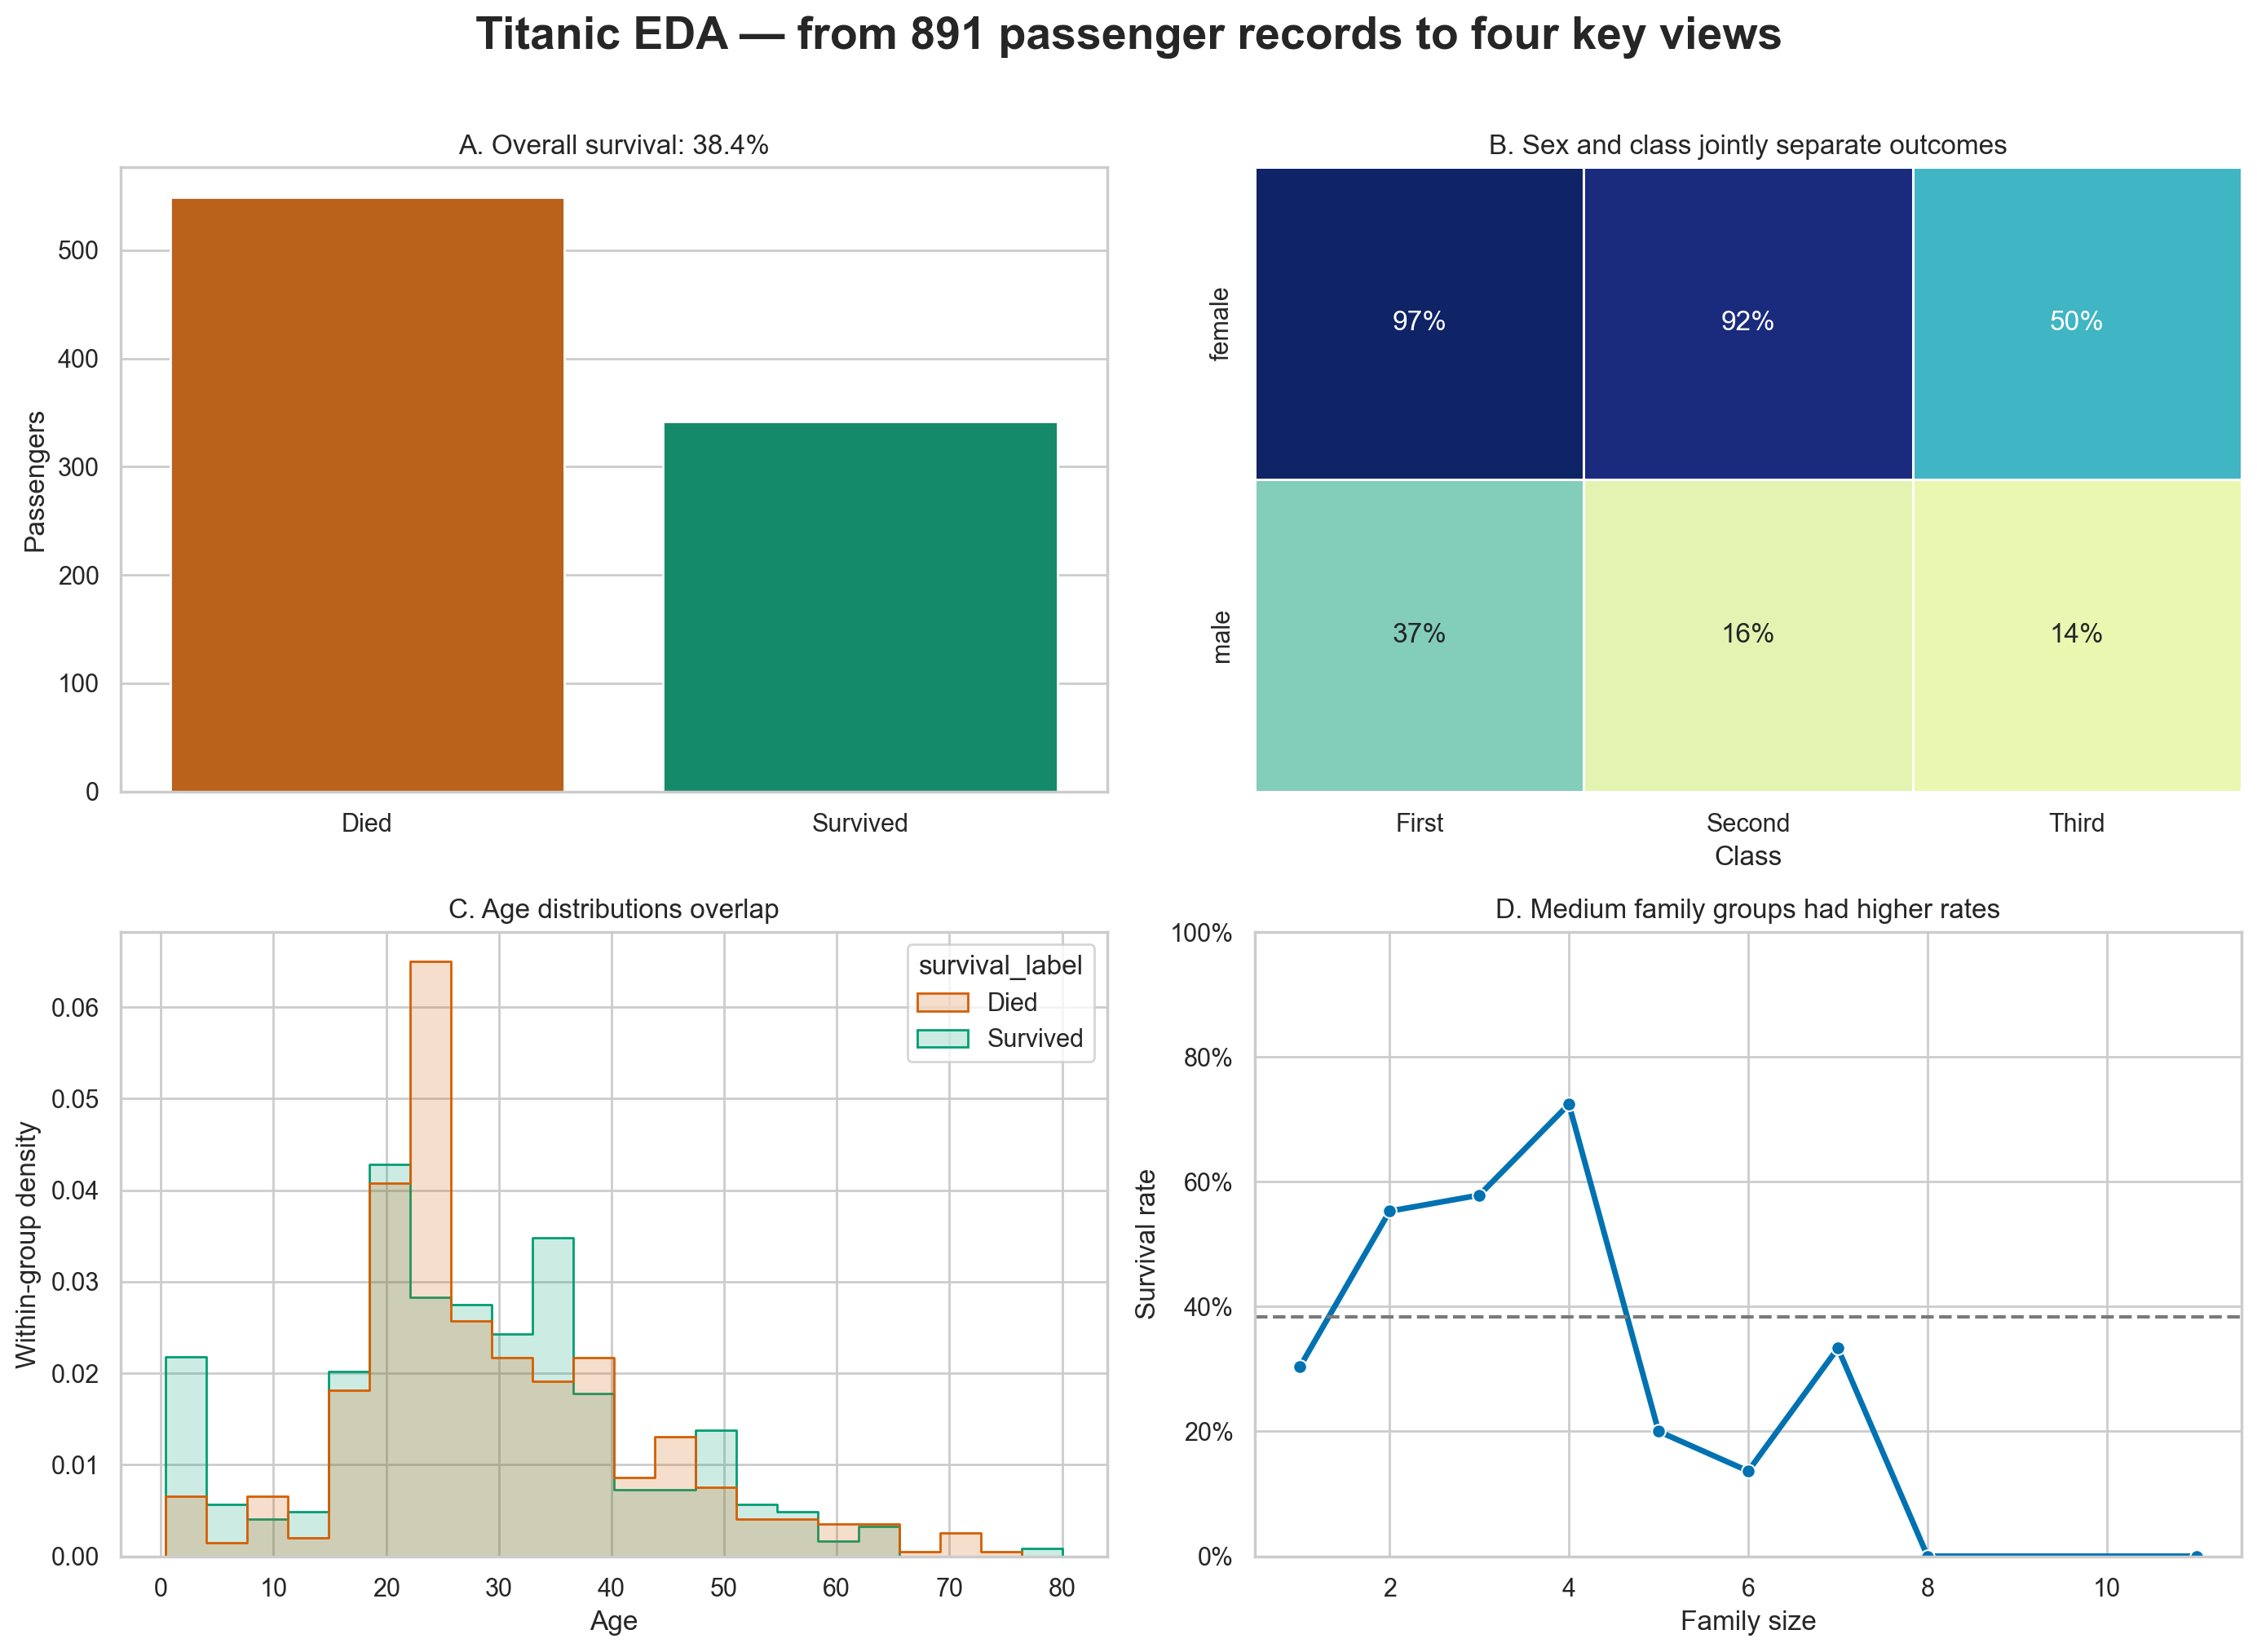

In [25]:
# VISUAL 14 — A presentation-ready summary dashboard.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# A. Outcome count
sns.countplot(data=df, x="survival_label", hue="survival_label", palette=[COLORS["died"], COLORS["survived"]], legend=False, ax=axes[0, 0])
axes[0, 0].set(title=f"A. Overall survival: {overall_rate:.1%}", xlabel="", ylabel="Passengers")

# B. Sex × class heatmap
sns.heatmap(sex_class_survival, annot=True, fmt=".0%", cmap="YlGnBu", vmin=0, vmax=1, cbar=False, linewidths=1, ax=axes[0, 1])
axes[0, 1].set(title="B. Sex and class jointly separate outcomes", xlabel="Class", ylabel="")

# C. Age distribution
sns.histplot(data=df, x="age", hue="survival_label", hue_order=["Died", "Survived"], palette=[COLORS["died"], COLORS["survived"]], bins=22, element="step", stat="density", common_norm=False, alpha=0.2, ax=axes[1, 0])
axes[1, 0].set(title="C. Age distributions overlap", xlabel="Age", ylabel="Within-group density")

# D. Family size
sns.lineplot(data=family_summary, x="family_size", y="survival_rate", marker="o", color=COLORS["primary"], linewidth=2.5, ax=axes[1, 1])
axes[1, 1].axhline(overall_rate, color=COLORS["neutral"], linestyle="--")
axes[1, 1].set(title="D. Medium family groups had higher rates", xlabel="Family size", ylabel="Survival rate", ylim=(0, 1))
axes[1, 1].yaxis.set_major_formatter(PercentFormatter(1))

fig.suptitle("Titanic EDA — from 891 passenger records to four key views", fontsize=20, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 11. Generate findings from the processed data

The text below is calculated from the DataFrame rather than typed from memory. If the data changes, the report changes with it.

In [26]:
female_rate = df.loc[df["sex"].eq("female"), "survived"].mean()
male_rate = df.loc[df["sex"].eq("male"), "survived"].mean()
first_rate = df.loc[df["pclass"].eq(1), "survived"].mean()
third_rate = df.loc[df["pclass"].eq(3), "survived"].mean()
best_family = family_summary.loc[family_summary["passengers"].ge(20)].sort_values("survival_rate", ascending=False).iloc[0]

print("TITANIC EDA — DATA-GENERATED FINDINGS")
print("=" * 45)
print(f"1. {overall_rate:.1%} of the {len(df):,} passengers in this dataset survived.")
print(f"2. Female survival was {female_rate:.1%}, compared with {male_rate:.1%} for males.")
print(f"3. First-class survival was {first_rate:.1%}, compared with {third_rate:.1%} in third class.")
print(f"4. Among family-size groups with at least 20 passengers, size {int(best_family['family_size'])} had the highest survival rate ({best_family['survival_rate']:.1%}).")
print(f"5. Age had a weak linear relationship with survival in complete records (r = {raw_age_survival_corr:.2f}) and after group-median imputation (r = {imputed_age_survival_corr:.2f}).")
print("\nCaution: These are associations in an incomplete historical passenger dataset, not causal estimates.")

TITANIC EDA — DATA-GENERATED FINDINGS
1. 38.4% of the 891 passengers in this dataset survived.
2. Female survival was 74.2%, compared with 18.9% for males.
3. First-class survival was 63.0%, compared with 24.2% in third class.
4. Among family-size groups with at least 20 passengers, size 4 had the highest survival rate (72.4%).
5. Age had a weak linear relationship with survival in complete records (r = -0.08) and after group-median imputation (r = -0.06).

Caution: These are associations in an incomplete historical passenger dataset, not causal estimates.


## 12. What Python did from start to finish

| Stage | Python operation | Why it matters |
|---|---|---|
| Load | `pd.read_csv(url)` | Converts CSV text into rows and typed columns |
| Inspect | `head`, `shape`, `dtypes`, `info`, `describe` | Reveals structure before assumptions are made |
| Audit | `isna`, `duplicated`, range checks | Finds quality risks that could distort results |
| Clean | grouped median, mode, explicit `Unknown` | Handles missingness transparently while preserving rows |
| Transform | `assign`, `pd.cut`, `np.log1p` | Creates concepts that are easier to analyze |
| Summarize | `groupby`, `agg`, `pivot_table`, `corr` | Compresses many records into comparable evidence |
| Visualize | Matplotlib + Seaborn | Makes distributions and group differences visible |
| Validate | `assert` | Confirms the processed data obeys key assumptions |
| Explain | calculated report text | Connects statistical output to plain-language findings |

### Good visualization habits used here

1. Match chart type to data type: categories → bars; numbers → histograms/boxplots/scatterplots.
2. Label axes with units and make titles state the question or finding.
3. Show denominators or sample sizes when comparing rates.
4. Use consistent colors for the same outcome across charts.
5. Treat transformations (such as log fare) as a viewing tool, not a way to delete inconvenient data.
6. State uncertainty and avoid causal language in observational EDA.

## Practice challenges

1. Compare survival for passengers travelling **alone** versus **with family**.
2. Add passenger count labels to the age-group chart.
3. Create a 100% stacked bar chart of survival within each passenger class.
4. Re-run the notebook with a different fill strategy for age. Which conclusions change?
5. Write three sentences explaining one chart to a non-technical audience.

**Next:** Day 3 uses cleaned features to build and evaluate a machine-learning model.